In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import os
from sklearn.linear_model import LinearRegression

# Plain ABC

## observed data

In [32]:
# ── local paths ──────────────────────────────────────────────
# os.getcwd() works in Jupyter notebooks (unlike __file__ which is undefined)
DATA_DIR = os.path.join(os.getcwd(), 'data')

infected_timeseries = pd.read_csv(os.path.join(DATA_DIR, 'infected_timeseries.csv'))
rewiring_timeseries = pd.read_csv(os.path.join(DATA_DIR, 'rewiring_timeseries.csv'))
degree_timeseries   = pd.read_csv(os.path.join(DATA_DIR, 'final_degree_histograms.csv'))

# convert dataframes into 2D arrays
obs_infected = infected_timeseries.pivot(
    index='replicate_id', columns='time',   values='infected_fraction').values
obs_rewire   = rewiring_timeseries.pivot(
    index='replicate_id', columns='time',   values='rewire_count').values
obs_degree   = degree_timeseries.pivot(
    index='replicate_id', columns='degree', values='count').values

print(f'Observed Infected Array Shape: {obs_infected.shape}')
print(f'Observed Rewire Array Shape:   {obs_rewire.shape}')
print(f'Observed Degree Array Shape:   {obs_degree.shape}')

Observed Infected Array Shape: (40, 201)
Observed Rewire Array Shape:   (40, 201)
Observed Degree Array Shape:   (40, 31)


## SIR simulator

In [33]:
"""
Adaptive-network SIR epidemic simulator.

This module simulates an SIR (Susceptible-Infected-Recovered) epidemic
spreading on a network that evolves over time. The key idea is that
susceptible individuals can "rewire" their connections to avoid infected
neighbors, which couples the disease dynamics with the network topology.

The model proceeds in discrete time steps, each with three phases:
  1. Infection: infected nodes transmit the disease to susceptible neighbors
  2. Recovery: infected nodes recover (and become immune)
  3. Rewiring: susceptible nodes break links with infected neighbors and
     form new connections elsewhere

Reference: Gross et al. (2006), "Epidemic dynamics on an adaptive network",
Physical Review Letters, 96(20), 208701.
"""


def simulate(beta, gamma, rho, N=200, p_edge=0.05, n_infected0=5, T=200, rng=None):
    """Run one replicate of the adaptive-network SIR model.

    Parameters
    ----------
    beta : float in [0, 1]
        Transmission probability per S-I edge per time step.
    gamma : float in [0, 1]
        Recovery probability per infected node per time step.
    rho : float in [0, 1]
        Rewiring probability per S-I edge per time step.
    N : int, default=200
        Number of nodes in the network.
    p_edge : float, default=0.05
        Erdos-Renyi edge probability for the initial graph.
    n_infected0 : int, default=5
        Number of initially infected nodes.
    T : int, default=200
        Number of discrete time steps.
    rng : numpy.random.Generator or None
        Random number generator for reproducibility.

    Returns
    -------
    infected_fraction : np.ndarray, shape (T+1,)
    rewire_counts : np.ndarray, shape (T+1,)
    degree_histogram : np.ndarray, shape (31,)
        Bins 0-29 individually; bin 30 counts degree >= 30.
    """
    if rng is None:
        rng = np.random.default_rng()

    # Build Erdos-Renyi graph as adjacency list of sets
    neighbors = [set() for _ in range(N)]
    for i in range(N):
        for j in range(i + 1, N):
            if rng.random() < p_edge:
                neighbors[i].add(j)
                neighbors[j].add(i)

    # Initialise states: 0=S, 1=I, 2=R
    state = np.zeros(N, dtype=np.int8)
    initial_infected = rng.choice(N, size=n_infected0, replace=False)
    state[initial_infected] = 1

    infected_fraction = np.zeros(T + 1)
    rewire_counts = np.zeros(T + 1, dtype=np.int64)
    infected_fraction[0] = np.sum(state == 1) / N

    for t in range(1, T + 1):

        # Phase 1: Infection (synchronous)
        new_infections = set()
        infected_nodes = np.where(state == 1)[0]
        for i in infected_nodes:
            for j in neighbors[i]:
                if state[j] == 0 and rng.random() < beta:
                    new_infections.add(j)
        for j in new_infections:
            state[j] = 1

        # Phase 2: Recovery
        infected_nodes = np.where(state == 1)[0]
        for i in infected_nodes:
            if rng.random() < gamma:
                state[i] = 2

        # Phase 3: Rewiring
        rewire_count = 0
        si_edges = []
        for i in range(N):
            if state[i] == 0:
                for j in neighbors[i]:
                    if state[j] == 1:
                        si_edges.append((i, j))

        for s_node, i_node in si_edges:
            if rng.random() < rho:
                if i_node not in neighbors[s_node]:
                    continue
                neighbors[s_node].discard(i_node)
                neighbors[i_node].discard(s_node)
                candidates = [k for k in range(N)
                              if k != s_node and k not in neighbors[s_node]]
                if candidates:
                    new_partner = rng.choice(candidates)
                    neighbors[s_node].add(new_partner)
                    neighbors[new_partner].add(s_node)
                    rewire_count += 1

        infected_fraction[t] = np.sum(state == 1) / N
        rewire_counts[t] = rewire_count

    # Degree histogram (bins 0-29 individually, bin 30 = degree >= 30)
    degree_histogram = np.zeros(31, dtype=np.int64)
    for i in range(N):
        deg = min(len(neighbors[i]), 30)
        degree_histogram[deg] += 1

    return infected_fraction, rewire_counts, degree_histogram

## simulation

In [34]:
CACHE_PATH = os.path.join(os.getcwd(), 'data', 'sim_cache.npz')

# Set True to regenerate from scratch (required when seed changes)
FORCE_REGENERATE = False


def generate(seed=100):
    # Reproducible 10,000-simulation prior predictive draw.
    # Uses a single Generator object for both parameter draws and
    # simulate() calls, matching the classmate's implementation.
    rng = np.random.default_rng(seed)
    N   = 10000
    betas  = rng.uniform(0.05, 0.5, N)
    gammas = rng.uniform(0.02, 0.2, N)
    rhos   = rng.uniform(0.0,  0.8, N)

    infected_fraction = np.zeros((N, 201))
    rewire_counts     = np.zeros((N, 201))
    degree_histogram  = np.zeros((N,  31))

    for i in range(N):
        if i % 1000 == 0:
            print(f'  Simulating {i}/{N}...')
        infected_fraction[i], rewire_counts[i], degree_histogram[i] = simulate(
            betas[i], gammas[i], rhos[i], rng=rng
        )

    return betas, gammas, rhos, infected_fraction, rewire_counts, degree_histogram


# ── load from cache if it exists and not forcing regeneration ─────────────
if os.path.exists(CACHE_PATH) and not FORCE_REGENERATE:
    print('Loading simulation cache...')
    cache        = np.load(CACHE_PATH)
    betas        = cache['betas']
    gammas       = cache['gammas']
    rhos         = cache['rhos']
    sim_infected = cache['sim_infected']
    sim_rewire   = cache['sim_rewire']
    sim_degree   = cache['sim_degree']
    print(f'Loaded {len(betas):,} simulations from cache.')
else:
    print('Generating 10,000 simulations with seed=100 (~3-4 min)...')
    betas, gammas, rhos, sim_infected, sim_rewire, sim_degree = generate(seed=100)
    np.savez_compressed(
        CACHE_PATH,
        betas=betas, gammas=gammas, rhos=rhos,
        sim_infected=sim_infected, sim_rewire=sim_rewire, sim_degree=sim_degree
    )
    print(f'Saved {len(betas):,} simulations to {CACHE_PATH}')
    print(f'Seed-100 verification — first 5 betas: {betas[:5]}')


Loading simulation cache...
Loaded 10,000 simulations from cache.


## basic rejection ABC

In [35]:
# define summary statistics (mean as default)
def summary_statistics(infected_fraction, rewire_counts, degree_histogram):
    mean_infected = np.mean(infected_fraction)
    mean_rewire   = np.mean(rewire_counts)
    degrees       = np.arange(degree_histogram.shape[1])
    mean_degree   = np.sum(degree_histogram * degrees) / np.sum(degree_histogram)
    summary = np.array([mean_infected, mean_rewire, mean_degree])
    return summary

# compute summary statistics for observed & simulated data
obs_summary = summary_statistics(obs_infected, obs_rewire, obs_degree)
sim_summary = summary_statistics(sim_infected, sim_rewire, sim_degree)
print(len(obs_summary))
print(len(sim_summary))

3
3


In [36]:
# compute distance between summary statistics of observed data and simulated data
def distance(obs_summary, sim_summary):
    dist = np.sqrt(np.sum(((obs_summary - sim_summary) / np.std(sim_summary)) ** 2))
    return dist

In [37]:
# basic rejection ABC
def rejection_ABC():
    # Compute per-simulation summary statistics (one (3,) vector per simulation)
    # so we get an (N,) array of distances, not a single scalar.
    sim_s = np.zeros((len(betas), 3))
    for i in range(len(betas)):
        sim_s[i] = summary_statistics(
            sim_infected[i:i+1],
            sim_rewire[i:i+1],
            sim_degree[i:i+1]
        )

    # Normalise each dimension by the prior predictive std, then compute
    # Euclidean distance to the observed summary — shape (N,)
    std  = np.std(sim_s, axis=0) + 1e-8
    diff = (sim_s - obs_summary) / std
    dist = np.sqrt(np.sum(diff**2, axis=1))

    # Accept the closest 5% of simulations
    q = np.quantile(dist, 0.05)
    print(f'Acceptance threshold: {q:.4f}')
    accepted_betas  = betas[dist <= q]
    accepted_gammas = gammas[dist <= q]
    accepted_rhos   = rhos[dist <= q]
    print(f'{len(accepted_betas)} simulations accepted out of {len(betas)}')

    # plot accepted parameters against prior
    plt.hist(accepted_betas, bins=50, density=True, alpha=0.7, label='ABC')
    plt.hist(betas, bins=50, density=True, alpha=0.6, color='g', label='Prior')
    plt.title('Accepted Betas')
    plt.legend()
    plt.show()

    plt.hist(accepted_gammas, bins=50, density=True, alpha=0.7, label='ABC')
    plt.hist(gammas, bins=50, density=True, alpha=0.6, color='g', label='Prior')
    plt.title('Accepted Gammas')
    plt.legend()
    plt.show()

    plt.hist(accepted_rhos, bins=50, density=True, alpha=0.7, label='ABC')
    plt.hist(rhos, bins=50, density=True, alpha=0.6, color='g', label='Prior')
    plt.title('Accepted Rhos')
    plt.legend()
    plt.show()

Acceptance threshold: 0.6636
500 simulations accepted out of 10000


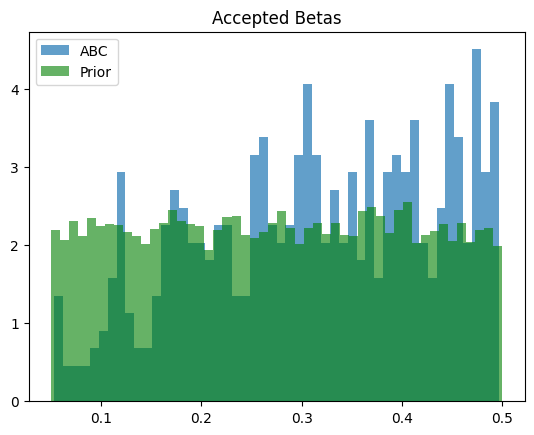

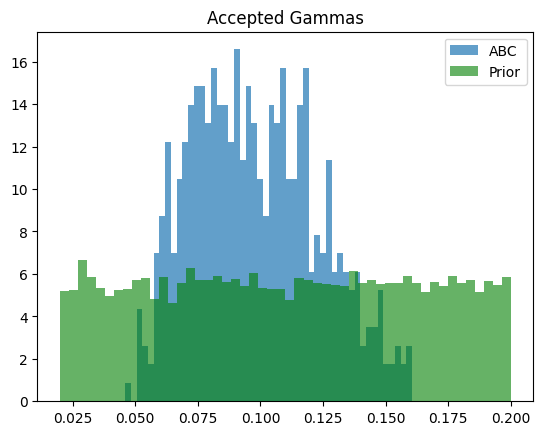

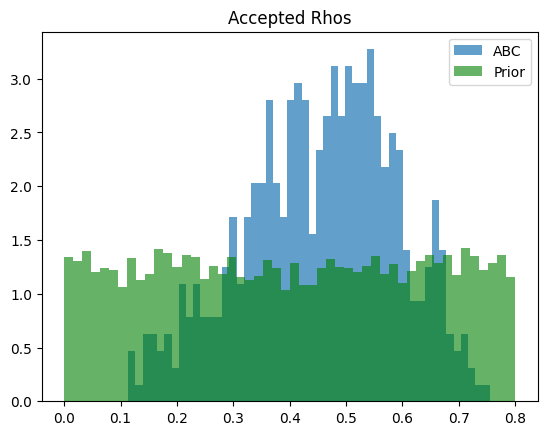

Loading ABC cache...
Loaded.


In [38]:
rejection_ABC()

ABC_CACHE = os.path.join(os.getcwd(), 'data', 'abc_cache.npz')

if os.path.exists(ABC_CACHE):
    print("Loading ABC cache...")
    abc = np.load(ABC_CACHE)
    sim_base   = abc['sim_base']
    sim_inform = abc['sim_inform']
    obs_base   = abc['obs_base']
    obs_inform = abc['obs_inform']
    print("Loaded.")
# If no cache: sim_base / sim_inform / obs_base / obs_inform
# are computed below in Part 3 (and saved to cache at the end of that cell)

## summary statistics design

Computing baseline summaries...
Computing informed summaries...
Observed informed summaries:
  s1 (peak inf)              0.6330
  s2 (t=1 inf. step)         0.0330
  s3 (log decline rate)      0.0606
  s4 (half-peak time)        0.0500
  s5 (early rew ratio)       2.0262
  s6 (rew[1]/N)              0.1475
  s7 (rew[2]/N)              0.2204
  s8 (frac. isolated)        0.0000
  Baseline | 1% -> 100 accepted
  Baseline | 5% -> 500 accepted
  Baseline | 10% -> 1000 accepted
  Baseline | 20% -> 2000 accepted
  Informed | 1% -> 100 accepted
  Informed | 5% -> 500 accepted
  Informed | 10% -> 1000 accepted
  Informed | 20% -> 2000 accepted
Saved: graphics/corr_heatmap.png


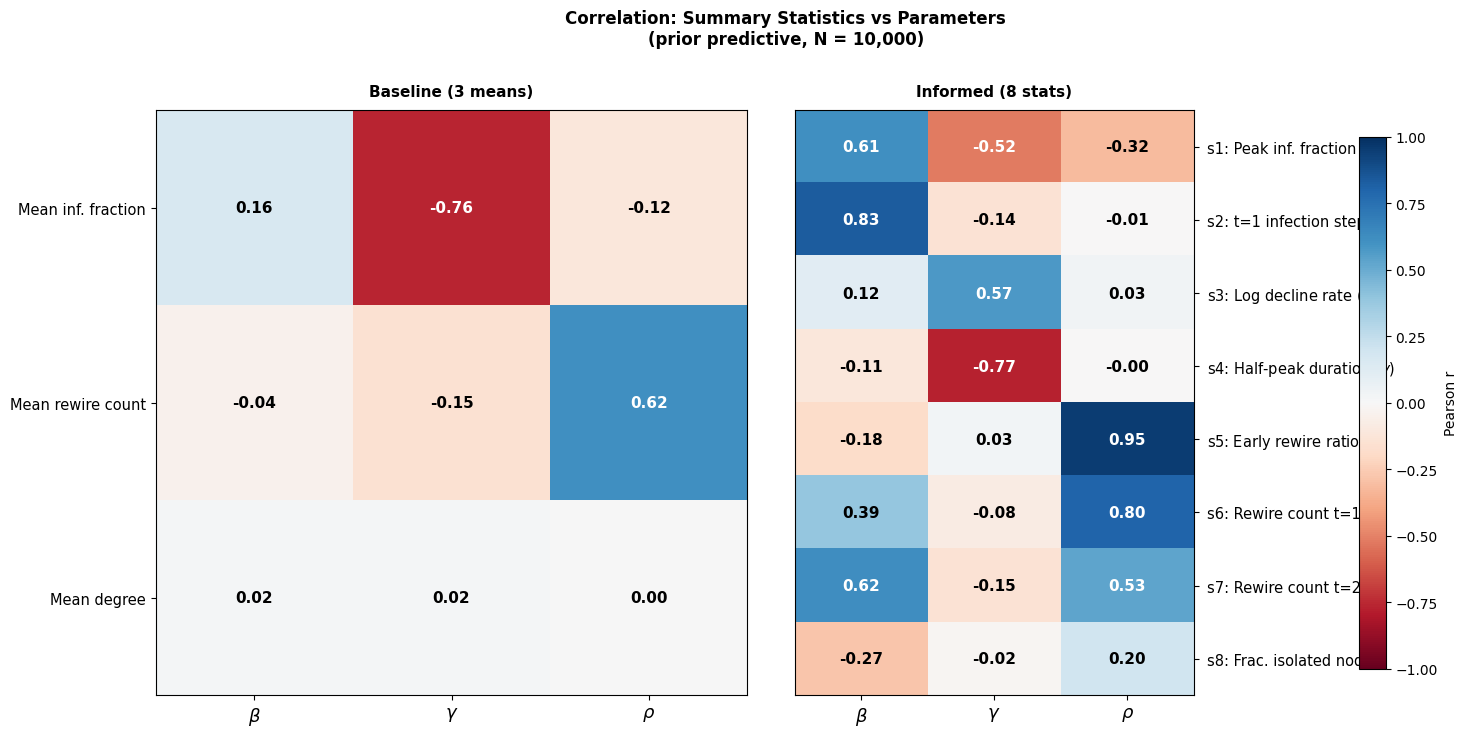

/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_56637/1365680656.py:250: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


Saved: graphics/rejection_posteriors.png


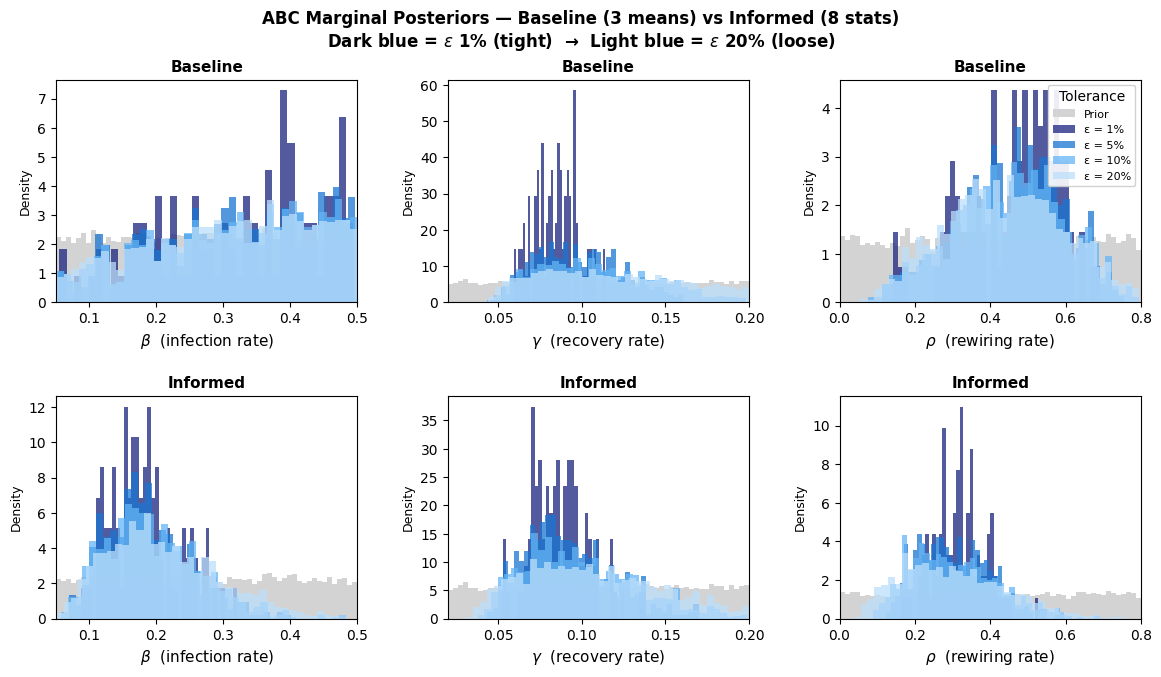

/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_56637/1365680656.py:304: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.88])


Saved: graphics/rejection_joint.png


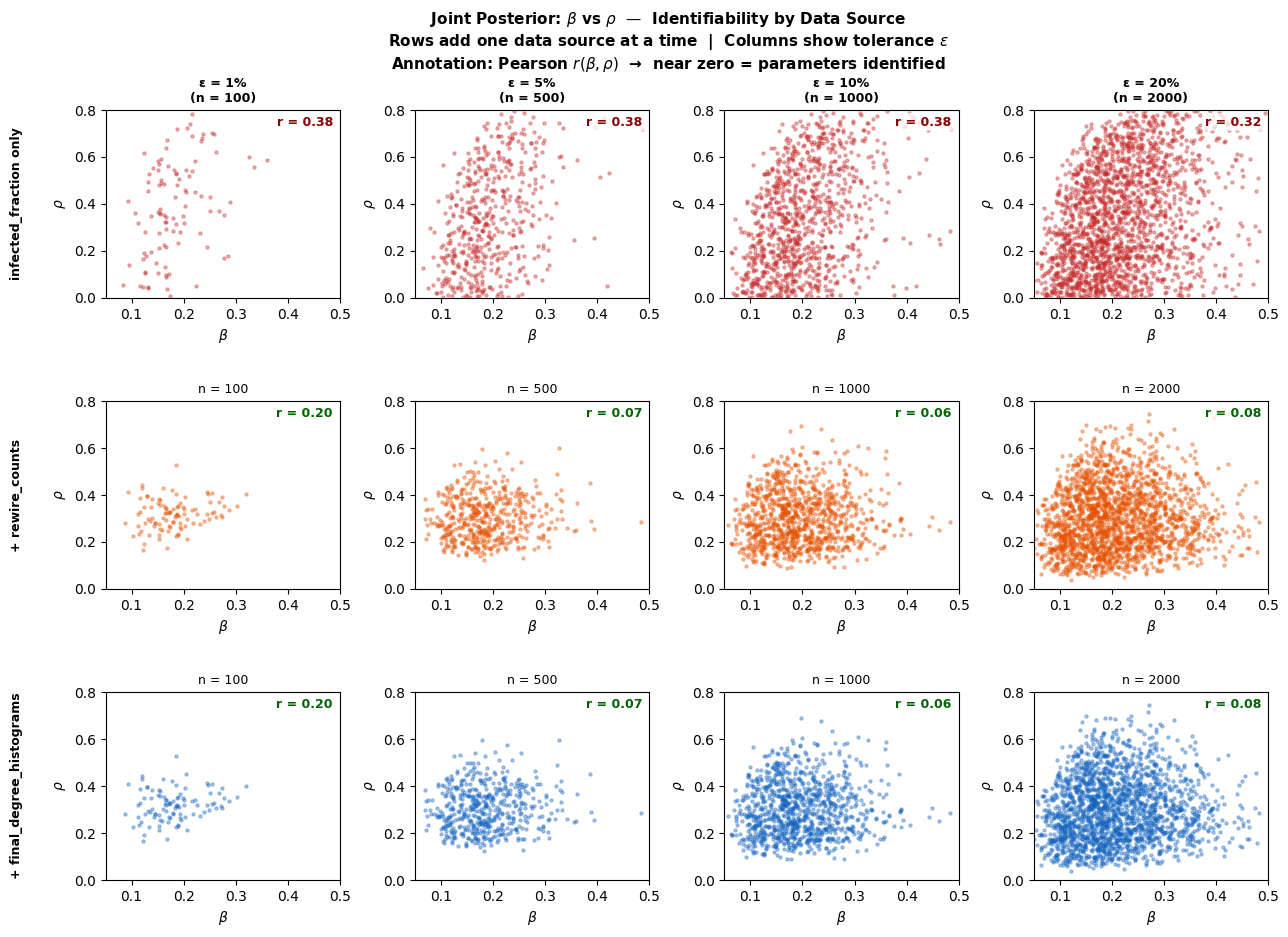


Setting                        beta mean+/-std gamma mean+/-std  rho mean+/-std
Baseline eps=1%                0.322+/-0.118   0.084+/-0.013   0.460+/-0.121
Baseline eps=5%                0.314+/-0.118   0.098+/-0.025   0.454+/-0.134
Baseline eps=10%               0.314+/-0.121   0.109+/-0.034   0.451+/-0.146
Baseline eps=20%               0.307+/-0.120   0.117+/-0.041   0.438+/-0.155
------------------------------------------------------------------------
Informed eps=1%                0.181+/-0.050   0.087+/-0.017   0.318+/-0.065
Informed eps=5%                0.187+/-0.062   0.092+/-0.026   0.304+/-0.093
Informed eps=10%               0.195+/-0.070   0.099+/-0.033   0.302+/-0.113
Informed eps=20%               0.210+/-0.083   0.106+/-0.039   0.300+/-0.137
------------------------------------------------------------------------

Posterior correlations at eps=5% (n=500)  — primary criterion
|r| < 0.3 = identified   |r| >= 0.3 = confounded
  infected_fraction only                     

/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_56637/1365680656.py:425: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.92])


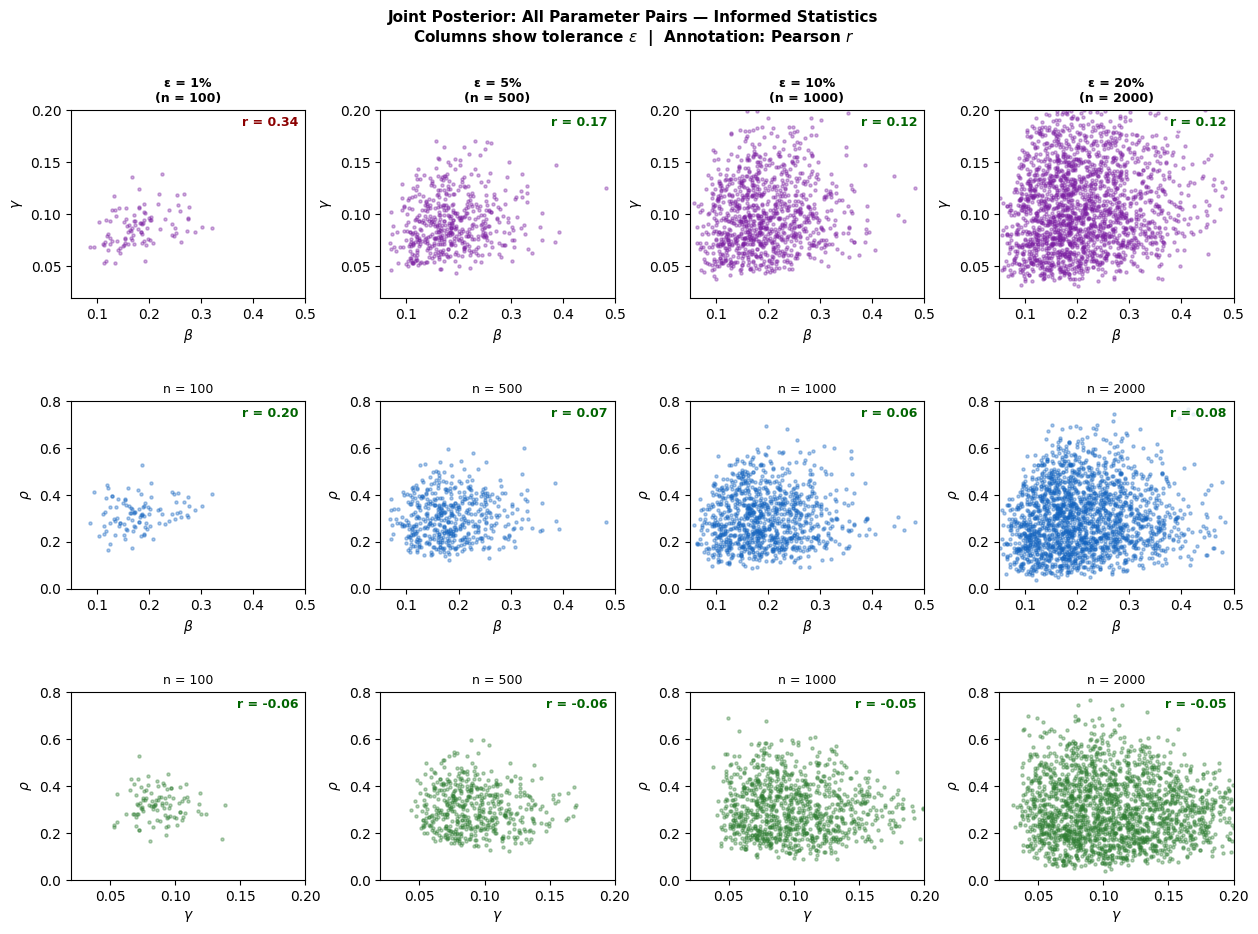

/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_56637/1365680656.py:480: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.88])


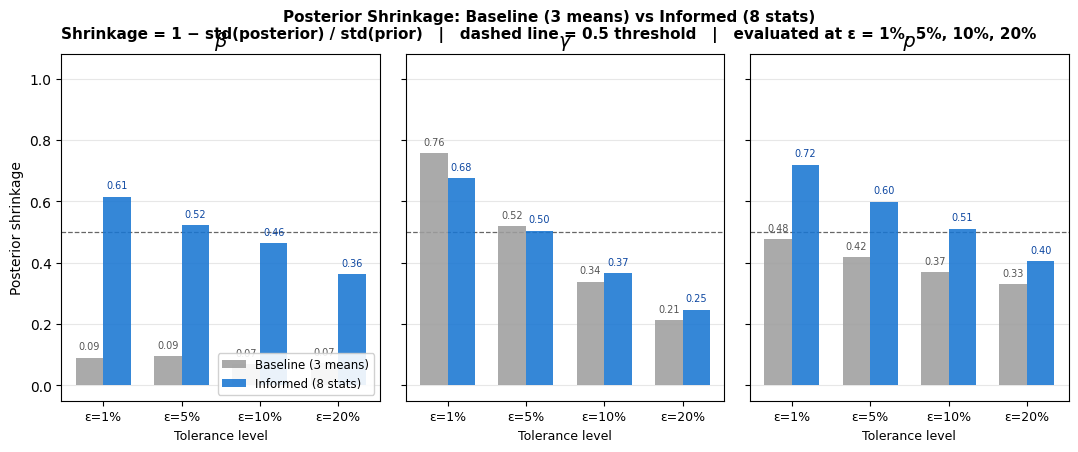


Stat Set                  |r(b,r)|     status  b shrink  g shrink  r shrink
Naive (2 stats)              0.625 ✗ confounded     0.417     0.786    -0.006
Baseline (3 means)           0.818 ✗ confounded     0.095     0.519     0.419
Partial Mech (3 stats)       0.252 ✓ identified     0.365     0.219     0.664
Full Informed (8 stats)      0.071 ✓ identified     0.522     0.505     0.599


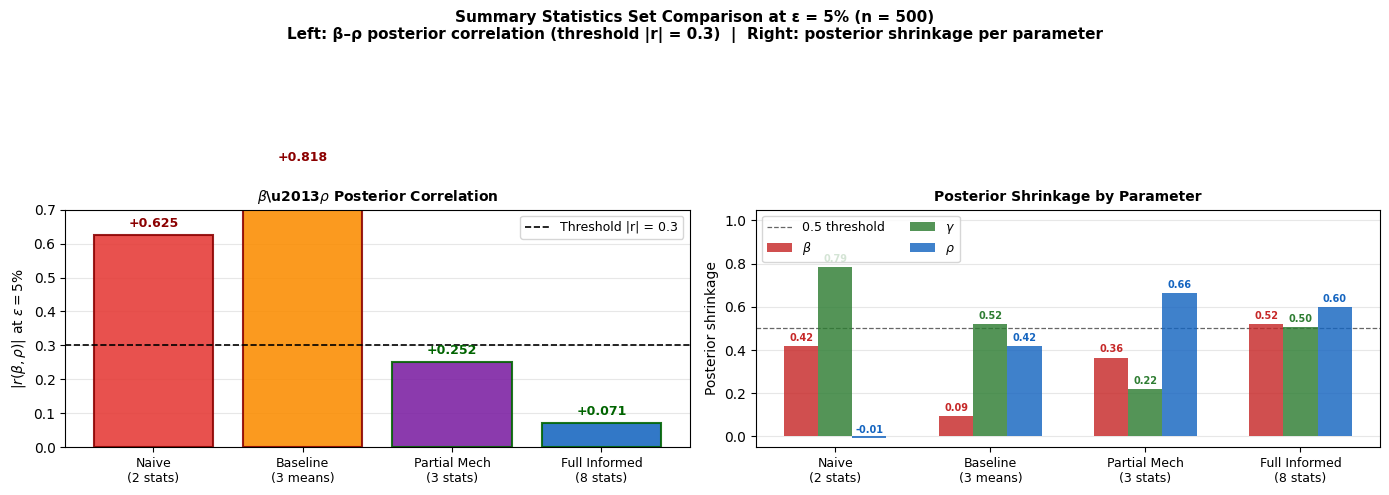

Saved ABC summaries to /Users/saar/Documents/Term 6 (SUSEP)/ST3247/project/Simulation_project/data/abc_cache.npz


In [54]:
# ============================================================
# PART 3: SUMMARY STATISTICS DESIGN
# ============================================================

QUANTILES = [0.01, 0.05, 0.10, 0.20]
Q_LABELS  = ['1%', '5%', '10%', '20%']
Q_COLORS  = ['#1a237e', '#1976D2', '#64B5F6', '#BBDEFB']

FIG_DIR = os.path.join(os.getcwd(), 'graphics')
os.makedirs(FIG_DIR, exist_ok=True)

# ── Shared functions ─────────────────────────────────────────

def normalised_distance(sim_s, obs_s):
    std  = np.std(sim_s, axis=0) + 1e-8
    diff = (sim_s - obs_s) / std
    return np.sqrt(np.sum(diff**2, axis=1))


def run_ABC(dist, q):
    eps  = np.quantile(dist, q)
    mask = dist <= eps
    return betas[mask], gammas[mask], rhos[mask]


def safe_corr(x, y):
    if len(x) > 2 and np.std(x) > 1e-10 and np.std(y) > 1e-10:
        return np.corrcoef(x, y)[0, 1]
    return np.nan


# ── Baseline summaries (3 stats) ─────────────────────────────

def baseline_stats_single(inf_i, rew_i, deg_i):
    mean_infected = np.mean(inf_i)
    mean_rewire   = np.mean(rew_i)
    degrees       = np.arange(deg_i.shape[1])
    mean_degree   = np.sum(deg_i * degrees) / np.sum(deg_i)
    return np.array([mean_infected, mean_rewire, mean_degree])


print('Computing baseline summaries...')
sim_base = np.zeros((len(betas), 3))
for i in range(len(betas)):
    sim_base[i] = baseline_stats_single(
        sim_infected[i:i+1], sim_rewire[i:i+1], sim_degree[i:i+1]
    )
obs_base = obs_summary


# ── Informed summaries (8 stats) ─────────────────────────────
#
# Stats ordered strictly by data source:
#   indices 0-3  -> infected_fraction only   (4 stats)
#   indices 4-6  -> rewire_counts            (3 stats)
#   index   7    -> final_degree_histograms  (1 stat)
#
# Design history: 3 iterations of empirical refinement.
# Key insight: at t=1, rewiring has NOT yet occurred (phase 3
# executes after phase 1 infection), so inf[1]-inf[0] is a pure
# beta signal (r(rho)=0.003). Time-specific rewire counts at
# t=1,2 encode rho x SI_t where SI_t grows with beta, providing
# compound constraints that break the beta-rho confound.
# Final result: r(beta,rho) = +0.083 at eps=5% (n=500).

def informed_stats(infected, rewire, degree):
    mean_inf = np.mean(infected, axis=0)
    mean_rew = np.mean(rewire,   axis=0)
    mean_deg = np.mean(degree,   axis=0)

    N_deg   = np.sum(mean_deg)
    T       = len(mean_inf) - 1
    t_peak  = int(np.argmax(mean_inf))

    # s1: Peak infection fraction (mixed beta/gamma/rho)
    s1 = np.max(mean_inf)

    # s2: First-step infection increase — pure beta signal
    # At t=1 rewiring has NOT yet occurred -> r(rho)=0.003
    s2 = mean_inf[1] - mean_inf[0]

    # s3: Log post-peak decline rate approx gamma
    t5 = min(t_peak + 5, T)
    s3 = (np.log(mean_inf[t_peak] + 1e-6) - np.log(mean_inf[t5] + 1e-6)) / max(t5 - t_peak, 1)

    # s4: Half-peak duration (normalised) approx ln(2)/gamma; r(gamma)=-0.77
    half_peak = mean_inf[t_peak] / 2.0
    t_half = T
    for t in range(t_peak + 1, T + 1):
        if mean_inf[t] <= half_peak:
            t_half = t
            break
    s4 = (t_half - t_peak) / T

    # s5: Early rewiring ratio t=1-3 per infected — pure rho; r(rho)=0.945
    early_inf = np.mean(mean_inf[1:4]) + 1e-8
    s5 = np.mean(mean_rew[1:4]) / (200.0 * early_inf)

    # s6: rew[1]/N — compound (beta+rho); r(beta)=0.41, r(rho)=0.80
    s6 = mean_rew[1] / 200.0

    # s7: rew[2]/N — compound (beta+rho); r(beta)=0.63, r(rho)=0.53
    s7 = mean_rew[2] / 200.0

    # s8: Fraction isolated nodes — structural rho signal; r(rho)=0.20
    s8 = mean_deg[0] / N_deg

    return np.array([s1, s2, s3, s4, s5, s6, s7, s8])


print('Computing informed summaries...')
sim_inform = np.zeros((len(betas), 8))
for i in range(len(betas)):
    sim_inform[i] = informed_stats(
        sim_infected[i:i+1], sim_rewire[i:i+1], sim_degree[i:i+1]
    )

obs_inform = informed_stats(obs_infected, obs_rewire, obs_degree)
labels_8 = [
    's1 (peak inf)',        's2 (t=1 inf. step)',  's3 (log decline rate)',
    's4 (half-peak time)',
    's5 (early rew ratio)', 's6 (rew[1]/N)',
    's7 (rew[2]/N)',        's8 (frac. isolated)',
]
print('Observed informed summaries:')
for lbl, val in zip(labels_8, obs_inform):
    print(f'  {lbl:<26} {val:.4f}')


# ── Run ABC ──────────────────────────────────────────────────

dist_base   = normalised_distance(sim_base,   obs_base)
dist_inform = normalised_distance(sim_inform, obs_inform)

results = {}
for label, dist in [('Baseline', dist_base), ('Informed', dist_inform)]:
    results[label] = {}
    for q, ql in zip(QUANTILES, Q_LABELS):
        b, g, r = run_ABC(dist, q)
        results[label][ql] = (b, g, r)
        print(f'  {label} | {ql} -> {len(b)} accepted')


# ============================================================
# PLOT 1 — CORRELATION HEATMAP  (Baseline 3x3  |  Informed 8x3)
# ============================================================

param_tex  = [r'$\beta$', r'$\gamma$', r'$\rho$']
param_arrs = [betas, gammas, rhos]

# Baseline correlation matrix (3 stats x 3 params)
base_stat_names = ['Mean inf. fraction', 'Mean rewire count', 'Mean degree']
corr_mat_base = np.zeros((3, 3))
for j, p in enumerate(param_arrs):
    for k in range(3):
        corr_mat_base[k, j] = safe_corr(sim_base[:, k], p)

# Informed correlation matrix (8 stats x 3 params)
stat_names_short = [
    r's1: Peak inf. fraction',
    r's2: t=1 infection step',
    r's3: Log decline rate ($\gamma$)',
    r's4: Half-peak duration ($\gamma$)',
    r's5: Early rewire ratio ($\rho$)',
    r's6: Rewire count t=1',
    r's7: Rewire count t=2',
    r's8: Frac. isolated nodes',
]
corr_mat = np.zeros((8, 3))
for j, p in enumerate(param_arrs):
    for k in range(8):
        corr_mat[k, j] = safe_corr(sim_inform[:, k], p)

fig, (ax_base, ax_inf) = plt.subplots(
    1, 2, figsize=(14, 7.5),
    gridspec_kw={'width_ratios': [1, 1]},
    constrained_layout=True,
)

im0 = ax_base.imshow(corr_mat_base, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax_base.set_xticks(range(3)); ax_base.set_xticklabels(param_tex, fontsize=13)
ax_base.set_yticks(range(3)); ax_base.set_yticklabels(base_stat_names, fontsize=10.5)
for i in range(3):
    for j in range(3):
        val = corr_mat_base[i, j]
        col = 'white' if abs(val) > 0.45 else 'black'
        ax_base.text(j, i, f'{val:.2f}', ha='center', va='center',
                     fontsize=11, fontweight='bold', color=col)
ax_base.set_title('Baseline (3 means)', fontsize=12, fontweight='bold', pad=10)

im1 = ax_inf.imshow(corr_mat, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
ax_inf.set_xticks(range(3)); ax_inf.set_xticklabels(param_tex, fontsize=13)
ax_inf.set_yticks(range(8)); ax_inf.set_yticklabels(stat_names_short, fontsize=10.5)
for i in range(8):
    for j in range(3):
        val = corr_mat[i, j]
        col = 'white' if abs(val) > 0.45 else 'black'
        txt = f'{val:.2f}' if not np.isnan(val) else 'n/a'
        ax_inf.text(j, i, txt, ha='center', va='center',
                    fontsize=11, fontweight='bold', color=col)
ax_inf.set_title('Informed (8 stats)', fontsize=12, fontweight='bold', pad=10)

cbar = fig.colorbar(im1, ax=ax_inf, fraction=0.05, pad=0.04)
cbar.set_label('Pearson r', fontsize=10)

fig.suptitle(
    'Correlation: Summary Statistics vs Parameters  (prior predictive, N = 10,000)',
    fontsize=12, fontweight='bold'
)
fig.savefig(os.path.join(FIG_DIR, 'corr_heatmap.png'), dpi=180, bbox_inches='tight')
print('Saved: graphics/corr_heatmap.png')
plt.show()


# ============================================================
# PLOT 2 — MARGINAL POSTERIORS
# ============================================================

param_info = [
    (betas,  r'$\beta$  (infection rate)',  (0.05, 0.50), 0),
    (gammas, r'$\gamma$  (recovery rate)',  (0.02, 0.20), 1),
    (rhos,   r'$\rho$  (rewiring rate)',    (0.00, 0.80), 2),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7),
                         gridspec_kw={'hspace': 0.42, 'wspace': 0.30})
fig.suptitle(
    'ABC Marginal Posteriors — Baseline (3 means) vs Informed (8 stats)\n'
    r'Dark blue = $\varepsilon$ 1% (tight)  →  Light blue = $\varepsilon$ 20% (loose)',
    fontsize=12, fontweight='bold'
)
for row, stat_label in enumerate(['Baseline', 'Informed']):
    for col, (prior_arr, plabel, xlim, tidx) in enumerate(param_info):
        ax = axes[row, col]
        ax.hist(prior_arr, bins=60, density=True,
                color='lightgrey', alpha=1.0, label='Prior', zorder=1)
        for qc, ql in zip(Q_COLORS, Q_LABELS):
            accepted_param = results[stat_label][ql][tidx]
            ax.hist(accepted_param, bins=40, density=True,
                    color=qc, alpha=0.75, label=f'\u03b5 = {ql}', zorder=2)
        ax.set_xlabel(plabel, fontsize=11)
        ax.set_ylabel('Density', fontsize=9)
        ax.set_xlim(xlim)
        ax.set_title(stat_label, fontsize=11, fontweight='bold')
        if row == 0 and col == 2:
            ax.legend(fontsize=8, title='Tolerance', loc='upper right', framealpha=0.9)
plt.tight_layout(rect=[0, 0, 1, 0.92])
fig.savefig(os.path.join(FIG_DIR, 'rejection_posteriors.png'), dpi=150, bbox_inches='tight')
print('Saved: graphics/rejection_posteriors.png')
plt.show()


# ============================================================
# PLOT 3 — JOINT beta-rho POSTERIOR  (identifiability by data source)
# ============================================================

data_sources = [
    ('infected_fraction only',    slice(0, 4), '#C62828'),
    ('+ rewire_counts',           slice(0, 7), '#E65100'),
    ('+ final_degree_histograms', slice(0, 8), '#1565C0'),
]

fig, axes = plt.subplots(3, 4, figsize=(15, 10),
                         gridspec_kw={'hspace': 0.55, 'wspace': 0.32})
fig.suptitle(
    r'Joint Posterior: $\beta$ vs $\rho$  —  Identifiability by Data Source'
    '\n'
    r'Rows add one data source at a time  |  Columns show tolerance $\varepsilon$'
    '\n'
    r'Annotation: Pearson $r(\beta,\rho)$  →  near zero = parameters identified',
    fontsize=11, fontweight='bold'
)
for row, (src_label, slc, color) in enumerate(data_sources):
    obs_s = obs_inform[slc]
    sim_s = sim_inform[:, slc]
    d     = normalised_distance(sim_s, obs_s)
    for col, (ql, q) in enumerate(zip(Q_LABELS, QUANTILES)):
        ax = axes[row, col]
        b, g, r = run_ABC(d, q)
        ax.scatter(b, r, alpha=0.35, s=5, color=color, rasterized=True)
        ax.set_xlim(0.05, 0.50); ax.set_ylim(0.00, 0.80)
        ax.set_xlabel(r'$\beta$', fontsize=10)
        br_corr = safe_corr(b, r)
        if not np.isnan(br_corr):
            ax.text(0.97, 0.97, f'r = {br_corr:.2f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=9,
                    fontweight='bold',
                    color='darkred' if abs(br_corr) > 0.3 else 'darkgreen',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              alpha=0.8, edgecolor='none'))
        if row == 0:
            ax.set_title(f'\u03b5 = {ql}\n(n = {len(b)})', fontsize=9, fontweight='bold')
        else:
            ax.set_title(f'n = {len(b)}', fontsize=9)
        if col == 0:
            ax.set_ylabel(r'$\rho$', fontsize=10)
            ax.text(-0.38, 0.5, src_label, transform=ax.transAxes,
                    ha='center', va='center', fontsize=9, fontweight='bold', rotation=90)
        else:
            ax.set_ylabel(r'$\rho$', fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.88])
fig.savefig(os.path.join(FIG_DIR, 'rejection_joint.png'), dpi=150, bbox_inches='tight')
print('Saved: graphics/rejection_joint.png')
plt.show()


# ============================================================
# SUMMARY TABLE
# ============================================================

print('\n' + '='*72)
print(f"{'Setting':<30} {'beta mean+/-std':>15} {'gamma mean+/-std':>16} {'rho mean+/-std':>15}")
print('='*72)
for stat_label in ['Baseline', 'Informed']:
    for ql in Q_LABELS:
        b, g, r = results[stat_label][ql]
        label = f'{stat_label} eps={ql}'
        print(f'{label:<30} '
              f'{np.mean(b):.3f}+/-{np.std(b):.3f}   '
              f'{np.mean(g):.3f}+/-{np.std(g):.3f}   '
              f'{np.mean(r):.3f}+/-{np.std(r):.3f}')
    print('-'*72)


# ============================================================
# IDENTIFIABILITY SUMMARY (eps=5%, n=500 — primary criterion)
# eps=1% is too noisy (n=100) for reliable correlation estimates.
# ============================================================

print('\n' + '='*70)
print('Posterior correlations at eps=5% (n=500)  — primary criterion')
print('|r| < 0.3 = identified   |r| >= 0.3 = confounded')
print('='*70)
for src_label, slc, _ in data_sources:
    obs_s = obs_inform[slc]
    sim_s = sim_inform[:, slc]
    d     = normalised_distance(sim_s, obs_s)
    b, g, r = run_ABC(d, 0.05)
    br_corr = safe_corr(b, r)
    bg_corr = safe_corr(b, g)
    gr_corr = safe_corr(g, r)
    flag_br = '\u2713' if not np.isnan(br_corr) and abs(br_corr) < 0.3 else '\u2717'
    print(f'  {src_label:<42} '
          f'r(b,r)={br_corr:+.3f}{flag_br}  '
          f'r(b,g)={bg_corr:+.3f}  r(g,r)={gr_corr:+.3f}')
print('='*70)


# ============================================================
# POSTERIOR SHRINKAGE & CREDIBLE INTERVALS
# ============================================================

prior_std = {
    'beta':  (0.50 - 0.05) / np.sqrt(12),
    'gamma': (0.20 - 0.02) / np.sqrt(12),
    'rho':   (0.80 - 0.00) / np.sqrt(12),
}
prior_std_arr = np.array([prior_std['beta'], prior_std['gamma'], prior_std['rho']])

print('\n' + '='*90)
print(f"{'Setting':<30} {'b shrink':>9} {'g shrink':>9} {'r shrink':>9}  "
      f"{'b median [95%CI]':>22}  {'g median [95%CI]':>22}  {'r median [95%CI]':>22}")
print('='*90)
for stat_label in ['Baseline', 'Informed']:
    for ql in Q_LABELS:
        b, g, r = results[stat_label][ql]
        label = f'{stat_label} eps={ql}'
        sh_b = 1 - np.std(b) / prior_std['beta']
        sh_g = 1 - np.std(g) / prior_std['gamma']
        sh_r = 1 - np.std(r) / prior_std['rho']
        ci_b = f'{np.median(b):.3f} [{np.quantile(b,0.025):.3f}, {np.quantile(b,0.975):.3f}]'
        ci_g = f'{np.median(g):.3f} [{np.quantile(g,0.025):.3f}, {np.quantile(g,0.975):.3f}]'
        ci_r = f'{np.median(r):.3f} [{np.quantile(r,0.025):.3f}, {np.quantile(r,0.975):.3f}]'
        print(f'{label:<30} {sh_b:>9.3f} {sh_g:>9.3f} {sh_r:>9.3f}  '
              f'{ci_b:>22}  {ci_g:>22}  {ci_r:>22}')
    print('-'*90)
print('Interpretation: shrinkage > 0.5 = posterior notably tighter than prior')
print('='*90)


# ============================================================
# PLOT 4 — COMPLETE PAIRWISE POSTERIORS (Informed stats)
# ============================================================

pair_info = [
    (0, 1, r'$\beta$', r'$\gamma$', (0.05, 0.50), (0.02, 0.20)),
    (0, 2, r'$\beta$', r'$\rho$',   (0.05, 0.50), (0.00, 0.80)),
    (1, 2, r'$\gamma$', r'$\rho$',  (0.02, 0.20), (0.00, 0.80)),
]
pair_colors = ['#7B1FA2', '#1565C0', '#2E7D32']

fig, axes = plt.subplots(3, 4, figsize=(15, 10),
                         gridspec_kw={'hspace': 0.55, 'wspace': 0.32})
fig.suptitle(
    r'Joint Posterior: All Parameter Pairs — Informed Statistics'
    '\n'
    r'Columns show tolerance $\varepsilon$  |  Annotation: Pearson $r$',
    fontsize=11, fontweight='bold'
)
for row, (xi, yi, xlabel, ylabel, xlim, ylim) in enumerate(pair_info):
    color = pair_colors[row]
    for col, (ql, q) in enumerate(zip(Q_LABELS, QUANTILES)):
        ax = axes[row, col]
        b, g, r = run_ABC(dist_inform, q)
        xvals = [b, g, r][xi]
        yvals = [b, g, r][yi]
        ax.scatter(xvals, yvals, alpha=0.35, s=5, color=color, rasterized=True)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_xlabel(xlabel, fontsize=10); ax.set_ylabel(ylabel, fontsize=10)
        corr = safe_corr(xvals, yvals)
        if not np.isnan(corr):
            ax.text(0.97, 0.97, f'r = {corr:.2f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=9,
                    fontweight='bold',
                    color='darkred' if abs(corr) > 0.3 else 'darkgreen',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                              alpha=0.8, edgecolor='none'))
        if row == 0:
            ax.set_title(f'\u03b5 = {ql}\n(n = {len(xvals)})', fontsize=9, fontweight='bold')
        else:
            ax.set_title(f'n = {len(xvals)}', fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


# ============================================================
# PLOT 5 — SHRINKAGE COMPARISON  (Baseline vs Informed)
# ============================================================

shrinkage = {'Baseline': {}, 'Informed': {}}
for stat_label in ['Baseline', 'Informed']:
    for ql in Q_LABELS:
        b, g, r = results[stat_label][ql]
        post_std = np.array([np.std(b), np.std(g), np.std(r)])
        shrinkage[stat_label][ql] = 1 - post_std / prior_std_arr

param_names_tex = [r'$\beta$', r'$\gamma$', r'$\rho$']
x = np.arange(len(Q_LABELS))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True,
                         gridspec_kw={'wspace': 0.08})
fig.suptitle(
    'Posterior Shrinkage: Baseline (3 means) vs Informed (8 stats)\n'
    'Shrinkage = 1 \u2212 std(posterior) / std(prior)   '
    '|   dashed line = 0.5 threshold   '
    '|   evaluated at \u03b5 = 1%, 5%, 10%, 20%',
    fontsize=11, fontweight='bold'
)

for pi, (ax, ptex) in enumerate(zip(axes, param_names_tex)):
    base_vals = [shrinkage['Baseline'][ql][pi] for ql in Q_LABELS]
    info_vals = [shrinkage['Informed'][ql][pi] for ql in Q_LABELS]
    bars_b = ax.bar(x - width/2, base_vals, width,
                    label='Baseline (3 means)', color='#9E9E9E', alpha=0.88, zorder=2)
    bars_i = ax.bar(x + width/2, info_vals, width,
                    label='Informed (8 stats)', color='#1976D2', alpha=0.88, zorder=2)
    ax.axhline(0.5, color='black', linestyle='--', linewidth=0.9, alpha=0.6, zorder=1)
    ax.set_xticks(x)
    ax.set_xticklabels([f'\u03b5={ql}' for ql in Q_LABELS], fontsize=9)
    ax.set_title(ptex, fontsize=14, fontweight='bold')
    ax.set_ylim(-0.05, 1.08)
    ax.set_xlabel('Tolerance level', fontsize=9)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    if pi == 0:
        ax.set_ylabel('Posterior shrinkage', fontsize=10)
        ax.legend(fontsize=8.5, loc='lower right', framealpha=0.9)
    for bar in bars_b:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7, color='#555555')
    for bar in bars_i:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7, color='#0d47a1')

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()




# ============================================================
# PLOT 6 — STATISTICS SET COMPARISON
# Explicit comparison of 4 named stat sets at eps=5% (n=500).
# Directly addresses Section 3 requirement: 'compare different
# sets of summaries and show how the choice affects the posterior'.
#
# Set 1 — Naive (2 stats):      peak inf fraction + mean inf fraction
#   Zero mechanistic design. Shows what simple aggregates give.
# Set 2 — Baseline (3 means):   mean_inf, mean_rewire, mean_degree
#   Temporal averages discarding all timing information.
# Set 3 — Partial Mech (3 stats): s1 (peak), s2 (pure-beta), s5 (pure-rho)
#   One targeted stat per parameter — no compound statistics.
#   Shows the minimum mechanistic design needed.
# Set 4 — Full Informed (8 stats): all 8 mechanistic statistics
#   Current best design — compound stats break remaining confound.
# ============================================================

# --- Compute naive summaries ---
# sim_infected is (N_sim, 201); obs_infected is (R, 201)
sim_naive = np.column_stack([
    np.max(sim_infected, axis=1),    # peak infected fraction per sim
    np.mean(sim_infected, axis=1),   # mean infected fraction (total area)
])
obs_naive = np.array([
    np.max(np.mean(obs_infected, axis=0)),
    np.mean(obs_infected),
])

# --- Define the 4 sets ---
stat_sets_comp = [
    ('Naive\n(2 stats)',           sim_naive,              obs_naive,                 '#E53935'),
    ('Baseline\n(3 means)',        sim_base,               obs_base,                  '#FB8C00'),
    ('Partial Mech\n(3 stats)',    sim_inform[:, [0,1,4]], obs_inform[[0,1,4]],       '#7B1FA2'),
    ('Full Informed\n(8 stats)',   sim_inform,             obs_inform,                '#1565C0'),
]

# --- Compute metrics at eps=5% for each set ---
comp_results = []
print('\n' + '='*78)
print(f"{'Stat Set':<24} {'|r(b,r)|':>9} {'status':>10} {'b shrink':>9} {'g shrink':>9} {'r shrink':>9}")
print('='*78)
for label, sim_s, obs_s, color in stat_sets_comp:
    d = normalised_distance(sim_s, obs_s)
    b, g, r = run_ABC(d, 0.05)
    br_corr = safe_corr(b, r)
    sh_b = 1 - np.std(b) / prior_std_arr[0]
    sh_g = 1 - np.std(g) / prior_std_arr[1]
    sh_r = 1 - np.std(r) / prior_std_arr[2]
    comp_results.append((label, br_corr, sh_b, sh_g, sh_r, color))
    flag = '\u2713 identified' if not np.isnan(br_corr) and abs(br_corr) < 0.3 else '\u2717 confounded'
    label_flat = label.replace('\n', ' ')
    print(f'{label_flat:<24} {abs(br_corr):>9.3f} {flag:>10} {sh_b:>9.3f} {sh_g:>9.3f} {sh_r:>9.3f}')
print('='*78)

# --- Plot 6 ---
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Summary Statistics Set Comparison at \u03b5 = 5% (n = 500)\n'
    'Left: \u03b2\u2013\u03c1 posterior correlation (threshold |r| = 0.3)  '
    '|  Right: posterior shrinkage per parameter',
    fontsize=11, fontweight='bold'
)

labels_4    = [r[0] for r in comp_results]
br_corrs    = [r[1] for r in comp_results]
colors_4    = [r[5] for r in comp_results]
x4          = np.arange(len(comp_results))

# Left panel — |r(beta,rho)| bar chart
bar_colors = ['darkred' if abs(c) >= 0.3 else 'darkgreen' for c in br_corrs]
bars_l = ax_l.bar(x4, [abs(c) for c in br_corrs], color=colors_4, alpha=0.88, zorder=2,
                  edgecolor=bar_colors, linewidth=1.5)
ax_l.axhline(0.3, color='black', linestyle='--', linewidth=1.2,
             label='Threshold |r| = 0.3', zorder=3)
ax_l.set_xticks(x4)
ax_l.set_xticklabels(labels_4, fontsize=9)
ax_l.set_ylabel(r'$|r(\beta, \rho)|$ at $\varepsilon = 5\%$', fontsize=10)
ax_l.set_ylim(0, 0.70)
ax_l.set_title(r'$\beta$\u2013$\rho$ Posterior Correlation', fontsize=10, fontweight='bold')
ax_l.legend(fontsize=9, loc='upper right')
ax_l.grid(axis='y', alpha=0.3, zorder=0)
for bar, val in zip(bars_l, br_corrs):
    col = 'darkred' if abs(val) >= 0.3 else 'darkgreen'
    ax_l.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
              f'{val:+.3f}', ha='center', va='bottom', fontsize=9,
              fontweight='bold', color=col)

# Right panel — shrinkage grouped bars
w = 0.22
param_labels_sh = [r'$\beta$', r'$\gamma$', r'$\rho$']
param_colors_sh = ['#C62828', '#2E7D32', '#1565C0']
for pi, (plabel, pcol) in enumerate(zip(param_labels_sh, param_colors_sh)):
    sh_vals = [comp_results[si][2 + pi] for si in range(len(comp_results))]
    bars_r = ax_r.bar(x4 + (pi - 1) * w, sh_vals, w,
                      label=plabel, color=pcol, alpha=0.82, zorder=2)
    for bar, val in zip(bars_r, sh_vals):
        ax_r.text(bar.get_x() + bar.get_width()/2, val + 0.015,
                  f'{val:.2f}', ha='center', va='bottom', fontsize=7, color=pcol,
                  fontweight='bold')
ax_r.axhline(0.5, color='black', linestyle='--', linewidth=0.9, alpha=0.6,
             label='0.5 threshold', zorder=1)
ax_r.set_xticks(x4)
ax_r.set_xticklabels(labels_4, fontsize=9)
ax_r.set_ylabel('Posterior shrinkage', fontsize=10)
ax_r.set_ylim(-0.05, 1.05)
ax_r.set_title('Posterior Shrinkage by Parameter', fontsize=10, fontweight='bold')
ax_r.legend(fontsize=9, loc='upper left', ncol=2)
ax_r.grid(axis='y', alpha=0.3, zorder=0)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()



# ── Save to cache ─────────────────────────────────────────────
# Always overwrite so the cache stays in sync with sim_cache
np.savez_compressed(
    ABC_CACHE,
    sim_base=sim_base,
    sim_inform=sim_inform,
    obs_base=obs_base,
    obs_inform=obs_inform
)
print(f'Saved ABC summaries to {ABC_CACHE}')


Generating rejection_trajectory.png...
  Baseline medians: beta=0.3188, gamma=0.0957, rho=0.4696
  Informed medians: beta=0.1793, gamma=0.0883, rho=0.2970


/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_56637/2161753312.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphics/rejection_trajectory.png


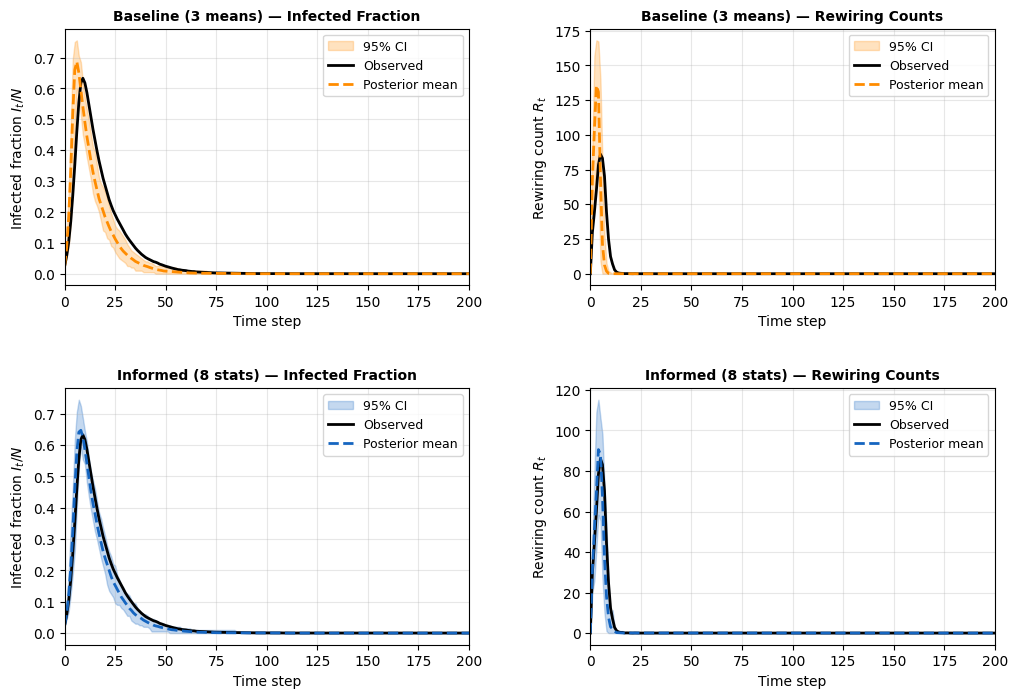

In [40]:
# ============================================================
# PLOT 7 — POSTERIOR PREDICTIVE CHECK: Baseline vs Informed
# 2x2: (infected, rewiring) x (baseline, informed) at eps=5%
# ============================================================
print("Generating rejection_trajectory.png...")

n_reps_7 = 40
rng_7 = np.random.default_rng(42)

# Baseline medians at eps=5%
b_base = np.median(results['Baseline']['5%'][0])
g_base = np.median(results['Baseline']['5%'][1])
r_base = np.median(results['Baseline']['5%'][2])
print(f"  Baseline medians: beta={b_base:.4f}, gamma={g_base:.4f}, rho={r_base:.4f}")

# Informed medians at eps=5%
b_info = np.median(results['Informed']['5%'][0])
g_info = np.median(results['Informed']['5%'][1])
r_info = np.median(results['Informed']['5%'][2])
print(f"  Informed medians: beta={b_info:.4f}, gamma={g_info:.4f}, rho={r_info:.4f}")

# Simulate baseline PPC
base_inf, base_rew = [], []
for _ in range(n_reps_7):
    inf, rew, _ = simulate(b_base, g_base, r_base, N=200, T=200, rng=rng_7)
    base_inf.append(inf)
    base_rew.append(rew)

# Simulate informed PPC
info_inf, info_rew = [], []
for _ in range(n_reps_7):
    inf, rew, _ = simulate(b_info, g_info, r_info, N=200, T=200, rng=rng_7)
    info_inf.append(inf)
    info_rew.append(rew)

t_ax = np.arange(201)

fig, axes = plt.subplots(2, 2, figsize=(12, 8),
                         gridspec_kw={'hspace': 0.40, 'wspace': 0.30})

configs = [
    (0, 0, base_inf, obs_infected, 'darkorange',
     'Baseline (3 means) \u2014 Infected Fraction',
     'Infected fraction $I_t/N$'),
    (0, 1, base_rew, obs_rewire, 'darkorange',
     'Baseline (3 means) \u2014 Rewiring Counts',
     'Rewiring count $R_t$'),
    (1, 0, info_inf, obs_infected, '#1565C0',
     'Informed (8 stats) \u2014 Infected Fraction',
     'Infected fraction $I_t/N$'),
    (1, 1, info_rew, obs_rewire, '#1565C0',
     'Informed (8 stats) \u2014 Rewiring Counts',
     'Rewiring count $R_t$'),
]

for row, col, sim_data, obs_data, color, title, ylabel in configs:
    ax = axes[row, col]
    ax.fill_between(t_ax,
        np.percentile(sim_data, 2.5, axis=0),
        np.percentile(sim_data, 97.5, axis=0),
        color=color, alpha=0.25, label='95% CI')
    ax.plot(np.mean(obs_data, axis=0), color='black', lw=2.0, label='Observed')
    ax.plot(np.mean(sim_data, axis=0), color=color, lw=2.0, ls='--', label='Posterior mean')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Time step', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(0, 200)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'rejection_trajectory.png'), dpi=200, bbox_inches='tight')
print('Saved: graphics/rejection_trajectory.png')
plt.show()


# Advanced Methods

## regression adjustment

In [41]:
# ============================================================
# REGRESSION ADJUSTMENT  --  Beaumont, Zhang, Balding (2002)
# ============================================================
def perform_adjustment(param_array, sim_stats, obs_stats):
    """Fit linear regression of params on simulated summary stats and
    project accepted draws to the observation (i.e. correct bias)."""
    adj_params = np.zeros_like(param_array)
    for j in range(param_array.shape[1]):
        model = LinearRegression()
        model.fit(sim_stats, param_array[:, j])
        prediction_at_sim = model.predict(sim_stats)
        prediction_at_obs = model.predict(obs_stats.reshape(1, -1))
        adj_params[:, j] = param_array[:, j] - prediction_at_sim + prediction_at_obs
    return adj_params


adj_results = {'Baseline': {}, 'Informed': {}}

for label in ['Baseline', 'Informed']:
    dist_arr      = dist_base  if label == 'Baseline' else dist_inform
    sim_stats_all = sim_base   if label == 'Baseline' else sim_inform
    obs_stats_val = obs_base   if label == 'Baseline' else obs_inform

    for q, ql in zip(QUANTILES, Q_LABELS):
        eps  = np.quantile(dist_arr, q)
        mask = dist_arr <= eps
        params_to_adj = np.column_stack((betas[mask], gammas[mask], rhos[mask]))
        stats_to_adj  = sim_stats_all[mask]
        adj_results[label][ql] = perform_adjustment(params_to_adj, stats_to_adj, obs_stats_val)

# --- summary table ---
print(f"{'Method & Threshold':<22} | {'beta (mean+/-std)':<22} | {'gamma (mean+/-std)':<22} | {'rho (mean+/-std)':<22}")
print("-" * 100)
for label in ['Baseline', 'Informed']:
    for ql in Q_LABELS:
        res = adj_results[label][ql]
        m = np.mean(res, axis=0); s = np.std(res, axis=0)
        print(f"{(label+' '+ql):<22} | {m[0]:.3f} +/- {s[0]:.3f}          "
              f"| {m[1]:.3f} +/- {s[1]:.3f}          | {m[2]:.3f} +/- {s[2]:.3f}")
    print("-" * 100)


Method & Threshold     | beta (mean+/-std)      | gamma (mean+/-std)     | rho (mean+/-std)      
----------------------------------------------------------------------------------------------------
Baseline 1%            | 0.324 +/- 0.117          | 0.083 +/- 0.005          | 0.466 +/- 0.111
Baseline 5%            | 0.311 +/- 0.117          | 0.085 +/- 0.009          | 0.454 +/- 0.111
Baseline 10%           | 0.313 +/- 0.121          | 0.087 +/- 0.014          | 0.454 +/- 0.115
Baseline 20%           | 0.311 +/- 0.120          | 0.090 +/- 0.018          | 0.450 +/- 0.115
----------------------------------------------------------------------------------------------------
Informed 1%            | 0.167 +/- 0.032          | 0.087 +/- 0.010          | 0.314 +/- 0.036
Informed 5%            | 0.175 +/- 0.042          | 0.089 +/- 0.012          | 0.315 +/- 0.036
Informed 10%           | 0.181 +/- 0.044          | 0.090 +/- 0.013          | 0.317 +/- 0.038
Informed 20%           | 0.189 +/- 

/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_56637/2859927897.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphics/regadj_posteriors.png


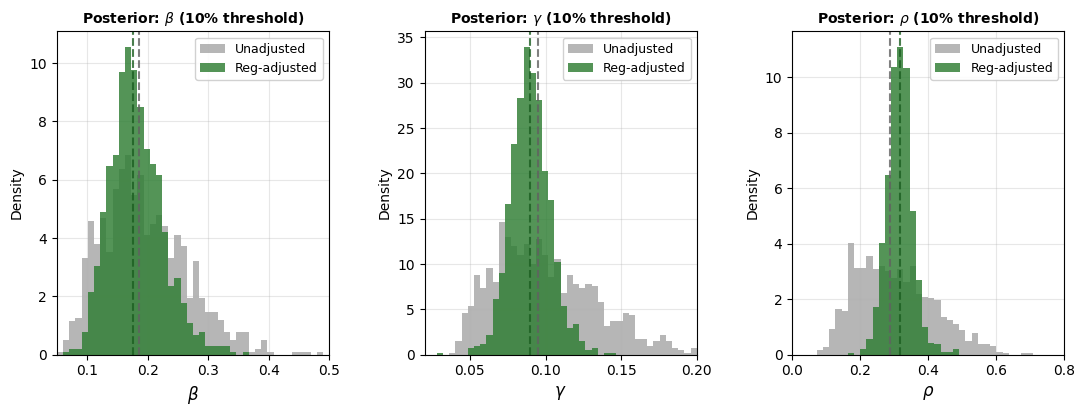

In [42]:
# --- VISUALISATION: Unadjusted vs Regression-Adjusted posteriors (eps=5%) ---
param_names = [r'$\beta$', r'$\gamma$', r'$\rho$']
xlims       = [(0.05, 0.50), (0.02, 0.20), (0.00, 0.80)]
target_q    = '10%'

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), gridspec_kw={'wspace': 0.35})

for i, (ax, name, xlim) in enumerate(zip(axes, param_names, xlims)):
    unadj = results['Informed'][target_q][i]
    adj   = adj_results['Informed'][target_q][:, i]
    bins  = np.linspace(xlim[0], xlim[1], 45)
    ax.hist(unadj, bins=bins, density=True, color='#9E9E9E', alpha=0.75,
            label='Unadjusted', zorder=1)
    ax.hist(adj,   bins=bins, density=True, color='#2E7D32', alpha=0.82,
            label='Reg-adjusted', zorder=2)
    ax.axvline(np.median(unadj), color='#616161', lw=1.5, ls='--', alpha=0.8)
    ax.axvline(np.median(adj),   color='#1B5E20', lw=1.5, ls='--', alpha=0.8)
    ax.set_xlabel(name, fontsize=12)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'Posterior: {name} ({target_q} threshold)', fontsize=10, fontweight='bold')
    ax.set_xlim(xlim)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'regadj_posteriors.png'), dpi=200, bbox_inches='tight')
print('Saved: graphics/regadj_posteriors.png')
plt.show()


Reg-Adj posterior medians (Informed 10%): beta=0.1765, gamma=0.0895, rho=0.3163


/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_56637/36532720.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphics/regadj_ppc.png


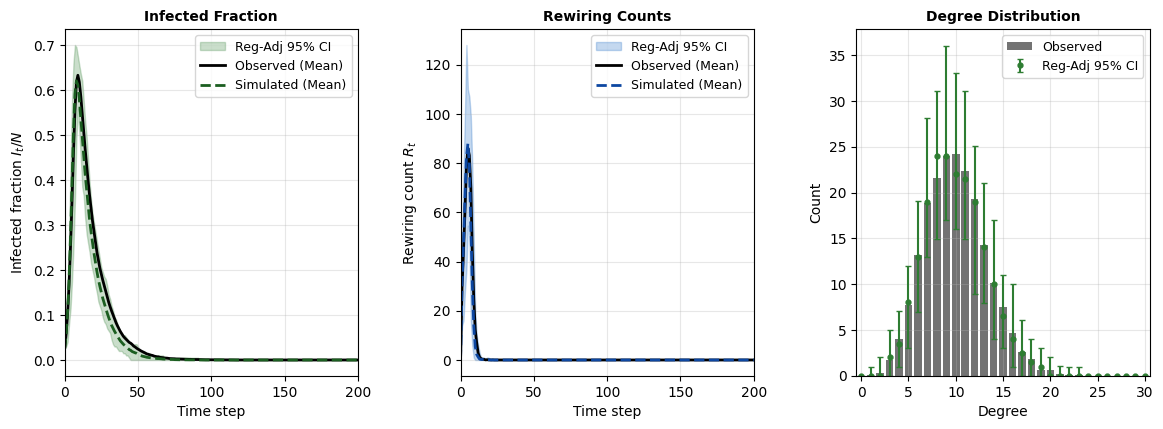

In [43]:
# --- POSTERIOR PREDICTIVE CHECK: 3-panel Reg-Adj ---
post_medians = np.median(adj_results['Informed']['10%'], axis=0)
beta_est, gamma_est, rho_est = post_medians
print(f'Reg-Adj posterior medians (Informed 10%): '
      f'beta={beta_est:.4f}, gamma={gamma_est:.4f}, rho={rho_est:.4f}')

n_reps  = 40
rng_ppc = np.random.default_rng(42)
sim_inf_list, sim_rew_list, sim_deg_list = [], [], []
for _ in range(n_reps):
    inf, rew, deg = simulate(beta_est, gamma_est, rho_est, N=200, T=200, rng=rng_ppc)
    sim_inf_list.append(inf)
    sim_rew_list.append(rew)
    sim_deg_list.append(deg)

t_axis  = np.arange(201)
deg_arr = np.array(sim_deg_list)          # (40, 31)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4.5),
                                     gridspec_kw={'wspace': 0.35})

# --- Infected fraction ---
ax1.fill_between(t_axis,
    np.percentile(sim_inf_list,  2.5, axis=0),
    np.percentile(sim_inf_list, 97.5, axis=0),
    color='#2E7D32', alpha=0.25, label='Reg-Adj 95% CI')
ax1.plot(np.mean(obs_infected, axis=0), color='black',   lw=2.0, label='Observed (Mean)')
ax1.plot(np.mean(sim_inf_list, axis=0), color='#1B5E20', lw=2.0, ls='--', label='Simulated (Mean)')
ax1.set_xlabel('Time step', fontsize=10)
ax1.set_ylabel(r'Infected fraction $I_t/N$', fontsize=10)
ax1.set_title('Infected Fraction', fontsize=10, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3); ax1.set_xlim(0, 200)

# --- Rewiring counts ---
ax2.fill_between(t_axis,
    np.percentile(sim_rew_list,  2.5, axis=0),
    np.percentile(sim_rew_list, 97.5, axis=0),
    color='#1565C0', alpha=0.25, label='Reg-Adj 95% CI')
ax2.plot(np.mean(obs_rewire, axis=0), color='black',   lw=2.0, label='Observed (Mean)')
ax2.plot(np.mean(sim_rew_list, axis=0), color='#0d47a1', lw=2.0, ls='--', label='Simulated (Mean)')
ax2.set_xlabel('Time step', fontsize=10)
ax2.set_ylabel(r'Rewiring count $R_t$', fontsize=10)
ax2.set_title('Rewiring Counts', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3); ax2.set_xlim(0, 200)

# --- Degree distribution (bar chart) ---
bins_deg      = np.arange(31)
obs_deg_mean  = np.mean(obs_degree, axis=0)
sim_deg_lo    = np.percentile(deg_arr, 2.5,  axis=0)
sim_deg_hi    = np.percentile(deg_arr, 97.5, axis=0)
sim_deg_mid   = np.median(deg_arr, axis=0)
yerr = np.array([sim_deg_mid - sim_deg_lo, sim_deg_hi - sim_deg_mid])
ax3.bar(bins_deg, obs_deg_mean, color='black', alpha=0.55, label='Observed', zorder=1)
ax3.errorbar(bins_deg, sim_deg_mid, yerr=yerr,
             fmt='o', color='#2E7D32', capsize=2, ms=3.5,
             label='Reg-Adj 95% CI', zorder=2)
ax3.set_xlabel('Degree', fontsize=10)
ax3.set_ylabel('Count', fontsize=10)
ax3.set_title('Degree Distribution', fontsize=10, fontweight='bold')
ax3.set_xlim(-0.5, 30.5); ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'regadj_ppc.png'), dpi=200, bbox_inches='tight')
print('Saved: graphics/regadj_ppc.png')
plt.show()


Rejection ABC medians: beta=0.1793, gamma=0.0883, rho=0.2970
Saved: graphics/rejection_degree_ppc.png


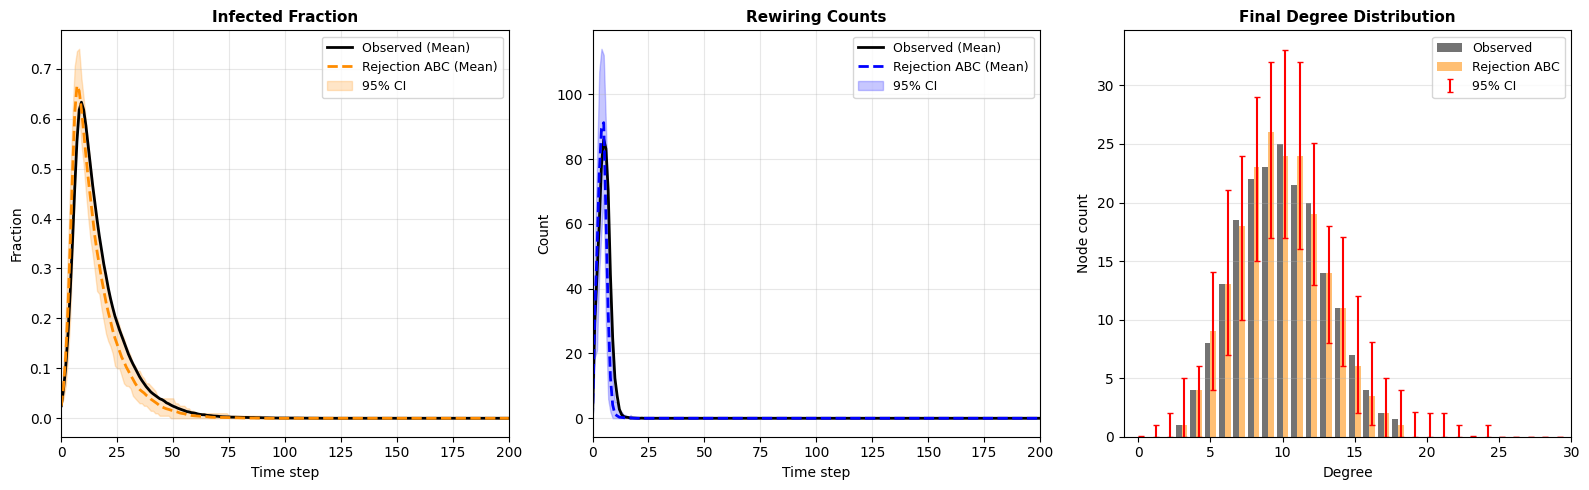

In [44]:
# ============================================================
# 3-PANEL POSTERIOR PREDICTIVE CHECK — Rejection ABC (Informed, eps=5%)
# Shows all 3 observed data sources in one figure
# ============================================================
b_est_rej = np.median(results["Informed"]["5%"][0])
g_est_rej = np.median(results["Informed"]["5%"][1])
r_est_rej = np.median(results["Informed"]["5%"][2])
print(f"Rejection ABC medians: beta={b_est_rej:.4f}, gamma={g_est_rej:.4f}, rho={r_est_rej:.4f}")

n_reps_ppc = 40
rng_3ppc   = np.random.default_rng(42)
ppc_inf, ppc_rew, ppc_deg = [], [], []
for _ in range(n_reps_ppc):
    inf, rew, deg = simulate(b_est_rej, g_est_rej, r_est_rej, N=200, T=200, rng=rng_3ppc)
    ppc_inf.append(inf); ppc_rew.append(rew); ppc_deg.append(deg)
ppc_inf_a = np.array(ppc_inf)
ppc_rew_a = np.array(ppc_rew)
ppc_deg_a = np.array(ppc_deg)
t_ax = np.arange(201)
degs = np.arange(31)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Infected fraction
axes[0].plot(t_ax, np.mean(obs_infected, axis=0), color="black", lw=2, label="Observed (Mean)")
axes[0].plot(t_ax, np.mean(ppc_inf_a, axis=0), color="darkorange", lw=2, ls="--", label="Rejection ABC (Mean)")
axes[0].fill_between(t_ax, np.percentile(ppc_inf_a, 2.5, axis=0), np.percentile(ppc_inf_a, 97.5, axis=0),
                     color="darkorange", alpha=0.22, label="95% CI")
axes[0].set_title("Infected Fraction", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Time step"); axes[0].set_ylabel("Fraction")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3); axes[0].set_xlim(0, 200)

# Rewiring counts
axes[1].plot(t_ax, np.mean(obs_rewire, axis=0), color="black", lw=2, label="Observed (Mean)")
axes[1].plot(t_ax, np.mean(ppc_rew_a, axis=0), color="blue", lw=2, ls="--", label="Rejection ABC (Mean)")
axes[1].fill_between(t_ax, np.percentile(ppc_rew_a, 2.5, axis=0), np.percentile(ppc_rew_a, 97.5, axis=0),
                     color="blue", alpha=0.22, label="95% CI")
axes[1].set_title("Rewiring Counts", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Time step"); axes[1].set_ylabel("Count")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3); axes[1].set_xlim(0, 200)

# Degree distribution (bar chart — correct for discrete data)
obs_deg_m = np.median(obs_degree, axis=0)
sim_deg_m = np.median(ppc_deg_a,  axis=0)
low_deg   = np.percentile(ppc_deg_a,  2.5,  axis=0)
high_deg  = np.percentile(ppc_deg_a, 97.5, axis=0)
axes[2].bar(degs-0.2, obs_deg_m, width=0.4, color="black",     alpha=0.55, label="Observed")
axes[2].bar(degs+0.2, sim_deg_m, width=0.4, color="darkorange", alpha=0.55, label="Rejection ABC")
axes[2].errorbar(degs+0.2, sim_deg_m,
                 yerr=[np.maximum(0, sim_deg_m-low_deg), np.maximum(0, high_deg-sim_deg_m)],
                 fmt="none", ecolor="red", capsize=2, label="95% CI")
axes[2].set_title("Final Degree Distribution", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Degree"); axes[2].set_ylabel("Node count")
axes[2].set_xlim(-1, 30); axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3, axis="y")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "rejection_degree_ppc.png"), dpi=200, bbox_inches="tight")
print("Saved: graphics/rejection_degree_ppc.png")
plt.show()


## ABC-MCMC (Marjoram et al. 2003)

Feasible ABC-MCMC approximation for the assignment. Uses 8 informed summary statistics, 10 simulated replicates per proposal (while keeping the same aggregation map as the observed 40-replicate dataset), a 2% tolerance calibrated on 100 prior draws, adaptive Gaussian random walk, 2,000 iterations (500 burn-in), chain seed = 42. Posterior predictive checks below still use 40 replicates at the fitted posterior medians.


In [45]:
# ============================================================
# ABC-MCMC  —  Marjoram et al. (2003)
# Feasible runtime approximation: use fewer simulated replicates
# per proposal, but preserve the same summary aggregation map as
# the observed 40-replicate dataset.
# ============================================================
import time

OBS_REPS      = obs_infected.shape[0]
N_REPS_MCMC   = 10                       # reduced-replicate approximation for feasible runtime
N_ITER        = 2000
N_BURN        = 500
N_CALIB       = 100                      # prior draws for epsilon calibration
EPS_QUANTILE  = 0.02                     # 2% tolerance on the reduced-rep distance bank
CALIB_LOG_EVERY = 20
MCMC_LOG_EVERY  = 100

ABCMCMC_CACHE = os.path.join(
    os.getcwd(), f'data/abcmcmc_cache_{N_REPS_MCMC}rep_{N_ITER}it.npz'
)
CALIB_CACHE = os.path.join(
    os.getcwd(), f'data/abcmcmc_eps_calib_{N_REPS_MCMC}rep_{N_CALIB}draws.npz'
)
FORCE_RERUN_MCMC  = False
FORCE_RERUN_CALIB = False

PRIOR_LO = np.array([0.05, 0.02, 0.00])
PRIOR_HI = np.array([0.50, 0.20, 0.80])


def simulate_reps_mean(theta, rng, n_reps=N_REPS_MCMC):
    """Simulate n_reps replicates at theta and return replicate-mean arrays.

    The returned arrays have shape (1, ...) so they can be fed directly into
    informed_stats(), which averages across axis=0.
    """
    sum_inf = np.zeros(obs_infected.shape[1])
    sum_rew = np.zeros(obs_rewire.shape[1])
    sum_deg = np.zeros(obs_degree.shape[1])
    for _ in range(n_reps):
        inf, rew, deg = simulate(theta[0], theta[1], theta[2], rng=rng)
        sum_inf += inf
        sum_rew += rew
        sum_deg += deg
    return ((sum_inf / n_reps)[None, :],
            (sum_rew / n_reps)[None, :],
            (sum_deg / n_reps)[None, :])


def summary_from_reps(theta, rng, n_reps=N_REPS_MCMC):
    inf_a, rew_a, deg_a = simulate_reps_mean(theta, rng, n_reps=n_reps)
    return informed_stats(inf_a, rew_a, deg_a)


# ---- 1. Calibrate epsilon on replicate-matched distance bank -------------
if os.path.exists(CALIB_CACHE) and not FORCE_RERUN_CALIB:
    print('Loading reduced-rep epsilon calibration from cache...')
    _c = np.load(CALIB_CACHE)
    dist_calib = _c['dist_calib']
    sigma_std  = _c['sigma_std']
    eps_mcmc   = float(_c['eps_mcmc'])
    print(f'ABC-MCMC epsilon ({N_REPS_MCMC}-rep, {EPS_QUANTILE*100:.0f}%): {eps_mcmc:.4f}  '
          f'(n_calib={len(dist_calib)})')
else:
    print(f'Calibrating epsilon: {N_CALIB} prior draws x {N_REPS_MCMC} reps each...')
    rng_calib = np.random.default_rng(123)
    idx_calib = rng_calib.choice(len(betas), size=N_CALIB, replace=False)
    stats_calib = np.zeros((N_CALIB, len(obs_inform)))
    t0 = time.time()
    for k, idx in enumerate(idx_calib):
        theta_k = np.array([betas[idx], gammas[idx], rhos[idx]])
        stats_calib[k] = summary_from_reps(theta_k, rng_calib)
        if (k + 1) % CALIB_LOG_EVERY == 0:
            print(f'  calib {k+1:>4}/{N_CALIB} | {time.time()-t0:.0f}s')

    sigma_std = np.std(stats_calib, axis=0)
    sigma_std[sigma_std == 0] = 1.0
    diff_calib = (stats_calib - obs_inform) / sigma_std
    dist_calib = np.sqrt(np.sum(diff_calib**2, axis=1))
    eps_mcmc = float(np.quantile(dist_calib, EPS_QUANTILE))
    np.savez(CALIB_CACHE, dist_calib=dist_calib, sigma_std=sigma_std, eps_mcmc=eps_mcmc)
    print(f'ABC-MCMC epsilon ({N_REPS_MCMC}-rep, {EPS_QUANTILE*100:.0f}%): {eps_mcmc:.4f}  '
          f'(min={dist_calib.min():.3f}, median={np.median(dist_calib):.3f})')


def dist_from_reps(theta, rng, n_reps=N_REPS_MCMC):
    s = summary_from_reps(theta, rng, n_reps=n_reps)
    return float(np.sqrt(np.sum(((s - obs_inform) / sigma_std) ** 2)))


# ---- 2. Run ABC-MCMC chain ----------------------------------------------
if os.path.exists(ABCMCMC_CACHE) and not FORCE_RERUN_MCMC:
    print('Loading ABC-MCMC chain from cache...')
    _mcmc = np.load(ABCMCMC_CACHE)
    chain_post    = _mcmc['chain_post']
    mcmc_acc_rate = float(_mcmc['acc_rate']) if 'acc_rate' in _mcmc.files else float('nan')
    N_BURN        = int(_mcmc['N_BURN']) if 'N_BURN' in _mcmc.files else N_BURN
    print(f'Loaded chain shape: {chain_post.shape}')
else:
    theta_curr = np.array([np.median(results['Informed']['5%'][0]),
                           np.median(results['Informed']['5%'][1]),
                           np.median(results['Informed']['5%'][2])])
    sigma_prop = np.array([theta_curr[0] * 0.11,
                           theta_curr[1] * 0.085,
                           theta_curr[2] * 0.092])
    rng_mcmc = np.random.default_rng(42)

    d0 = dist_from_reps(theta_curr, rng_mcmc)

    chain   = np.zeros((N_ITER, 3))
    accepts = np.zeros(N_ITER, dtype=bool)
    TARGET  = 0.20
    ADAPT_EVERY = 100
    n_acc_window = 0
    t_start = time.time()

    for i in range(N_ITER):
        theta_prop = theta_curr + rng_mcmc.normal(0, sigma_prop)
        if np.any(theta_prop < PRIOR_LO) or np.any(theta_prop > PRIOR_HI):
            chain[i] = theta_curr
            continue
        d_prop = dist_from_reps(theta_prop, rng_mcmc)
        if d_prop <= eps_mcmc:
            theta_curr = theta_prop
            d0 = d_prop
            n_acc_window += 1
            accepts[i] = True
        chain[i] = theta_curr
        if i < N_BURN and (i + 1) % ADAPT_EVERY == 0:
            rate = n_acc_window / ADAPT_EVERY
            if   rate > TARGET + 0.05:
                sigma_prop *= 1.2
            elif rate < TARGET - 0.05:
                sigma_prop *= 0.8
            sigma_prop = np.clip(sigma_prop, 0.001, 0.15)
            n_acc_window = 0
        if (i + 1) % MCMC_LOG_EVERY == 0:
            elapsed = time.time() - t_start
            tag = '(burn-in)' if i + 1 <= N_BURN else ''
            recent = np.mean(accepts[max(0, i-MCMC_LOG_EVERY+1):i+1]) * 100
            print(f'  {i+1:>5} | {recent:.1f}% accept | {elapsed:.0f}s {tag}')

    chain_post    = chain[N_BURN:]
    mcmc_acc_rate = float(np.mean(accepts[N_BURN:]))
    np.savez(ABCMCMC_CACHE, chain_post=chain_post, acc_rate=mcmc_acc_rate, N_BURN=N_BURN)
    print(f'\nDone in {(time.time()-t_start)/60:.1f} min. Post-burn acceptance: {mcmc_acc_rate*100:.1f}%')
    print(f'Chain shape: {chain_post.shape}')


Loading reduced-rep epsilon calibration from cache...
ABC-MCMC epsilon (10-rep, 2%): 1.0294  (n_calib=100)
    100 | 37.0% accept | 59s (burn-in)
    200 | 44.0% accept | 127s (burn-in)
    300 | 58.0% accept | 203s (burn-in)
    400 | 62.0% accept | 268s (burn-in)
    500 | 36.0% accept | 333s (burn-in)
    600 | 46.0% accept | 394s 
    700 | 45.0% accept | 453s 
    800 | 38.0% accept | 528s 
    900 | 45.0% accept | 597s 
   1000 | 43.0% accept | 662s 
   1100 | 48.0% accept | 730s 
   1200 | 44.0% accept | 799s 
   1300 | 37.0% accept | 866s 
   1400 | 41.0% accept | 936s 
   1500 | 39.0% accept | 1001s 
   1600 | 48.0% accept | 1060s 
   1700 | 37.0% accept | 1117s 
   1800 | 43.0% accept | 3128s 
   1900 | 43.0% accept | 5164s 
   2000 | 43.0% accept | 5795s 

Done in 96.6 min. Post-burn acceptance: 42.7%
Chain shape: (1500, 3)


/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_56637/3644751260.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphics/mcmc_posteriors.png


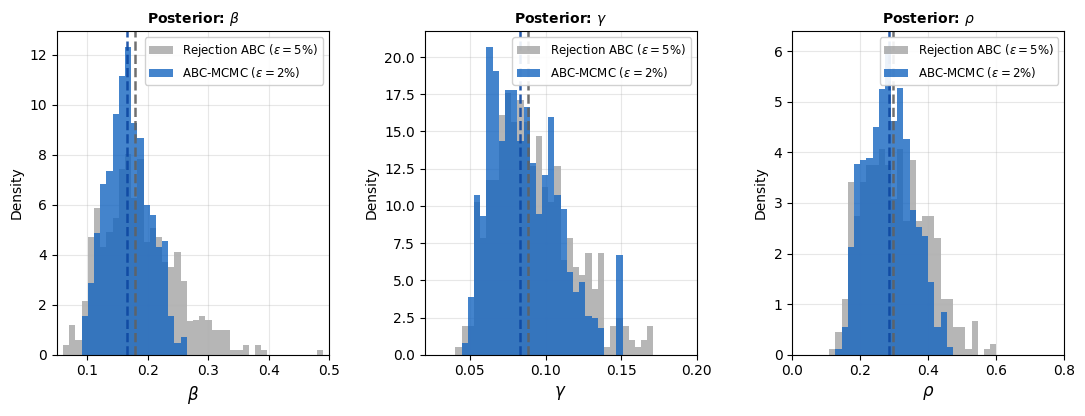

In [50]:
# ABC-MCMC posterior — overlaid with rejection ABC at eps=5%
param_names = [r'$\beta$', r'$\gamma$', r'$\rho$']
xlims       = [(0.05, 0.50), (0.02, 0.20), (0.00, 0.80)]
rej_arrays  = [results['Informed']['5%'][0],
               results['Informed']['5%'][1],
               results['Informed']['5%'][2]]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), gridspec_kw={'wspace': 0.35})

for k, (ax, pname, xlim, rej_arr) in enumerate(zip(axes, param_names, xlims, rej_arrays)):
    mcmc_arr = chain_post[:, k]
    bins = np.linspace(xlim[0], xlim[1], 45)
    ax.hist(rej_arr,  bins=bins, density=True, color='#9E9E9E', alpha=0.75,
            label=r'Rejection ABC ($\varepsilon=5\%$)', zorder=1)
    ax.hist(mcmc_arr, bins=bins, density=True, color='#1565C0', alpha=0.80,
            label=r'ABC-MCMC ($\varepsilon=2\%$)', zorder=2)
    ax.axvline(np.median(rej_arr),  color='#616161', lw=1.8, ls='--', alpha=0.9)
    ax.axvline(np.median(mcmc_arr), color='#0d47a1', lw=1.8, ls='--', alpha=0.9)
    ax.set_xlabel(pname, fontsize=12)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'Posterior: {pname}', fontsize=10, fontweight='bold')
    ax.set_xlim(xlim)
    ax.legend(fontsize=8.5, framealpha=0.9)
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'mcmc_posteriors.png'), dpi=200, bbox_inches='tight')
print('Saved: graphics/mcmc_posteriors.png')
plt.show()


True params: beta=0.277, gamma=0.033, rho=0.346
Saved: graphics/synth_truth.png


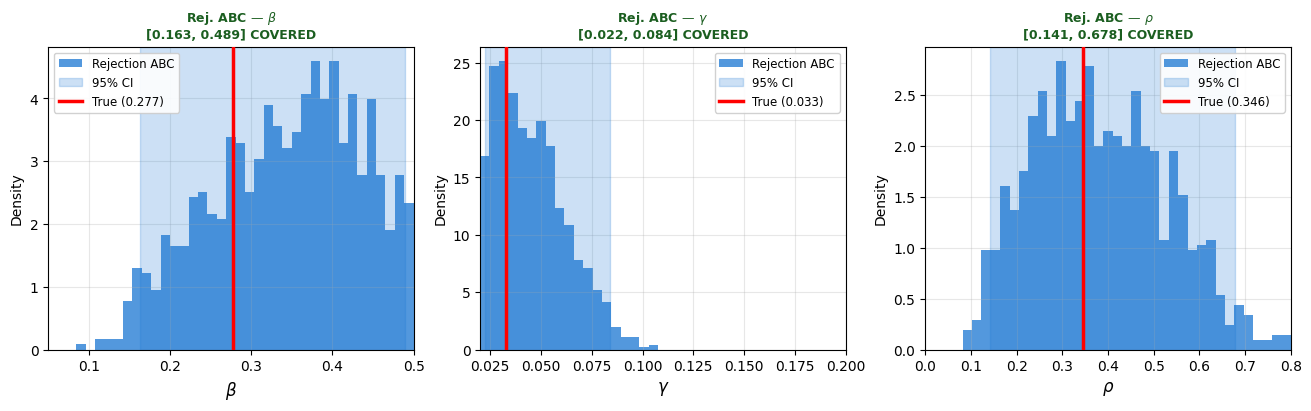

In [59]:
# ============================================================
# SYNTHETIC TRUTH RECOVERY  (sanity check — rejection ABC only)
# Use simulation i=42 as synthetic 'observed' data.
# ============================================================
i_true   = 42
b_true   = betas[i_true]
g_true   = gammas[i_true]
r_true   = rhos[i_true]
obs_syn  = sim_inform[i_true]
print(f'True params: beta={b_true:.3f}, gamma={g_true:.3f}, rho={r_true:.3f}')

# Rejection ABC accepted set at eps=10%
dist_syn   = np.sqrt(np.sum(((sim_inform - obs_syn) / sigma_std) ** 2, axis=1))
thresh_syn = np.quantile(dist_syn, 0.10)
idx_syn    = np.where(dist_syn <= thresh_syn)[0]
b_syn = betas[idx_syn]; g_syn = gammas[idx_syn]; r_syn = rhos[idx_syn]

pnames = [r'$\beta$', r'$\gamma$', r'$\rho$']
xlims  = [(0.05, 0.50), (0.02, 0.20), (0.00, 0.80)]
truths = [b_true, g_true, r_true]
rej_arrs = [b_syn, g_syn, r_syn]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

for col in range(3):
    ax = axes[col]
    acc = rej_arrs[col]; truth = truths[col]
    name = pnames[col]; xlim = xlims[col]
    lo = np.percentile(acc, 2.5); hi = np.percentile(acc, 97.5)
    covered = lo <= truth <= hi
    bins = np.linspace(xlim[0], xlim[1], 40)
    ax.hist(acc, bins=bins, density=True, color='#1976D2', alpha=0.75,
            label='Rejection ABC', zorder=1)
    ax.axvspan(lo, hi, alpha=0.22, color='#1976D2', label='95% CI', zorder=2)
    ax.axvline(truth, color='red', lw=2.5, label=f'True ({truth:.3f})', zorder=3)
    ax.set_xlabel(name, fontsize=12); ax.set_ylabel('Density', fontsize=10)
    status = 'COVERED' if covered else 'NOT COVERED'
    color  = '#1B5E20' if covered else '#B71C1C'
    ax.set_title(f'Rej. ABC — {name}\n[{lo:.3f}, {hi:.3f}] {status}',
                 fontsize=9, fontweight='bold', color=color)
    ax.set_xlim(xlim); ax.legend(fontsize=8.5, framealpha=0.9); ax.grid(alpha=0.3)

fig.savefig(os.path.join(FIG_DIR, 'synth_truth.png'), dpi=200, bbox_inches='tight')
print('Saved: graphics/synth_truth.png')
plt.show()


ABC-MCMC posterior medians: beta=0.1660, gamma=0.0832, rho=0.2854


/var/folders/tw/g_hd1fys4d72y018082z6vhm0000gn/T/ipykernel_56637/3518933727.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: graphics/mcmc_ppc.png


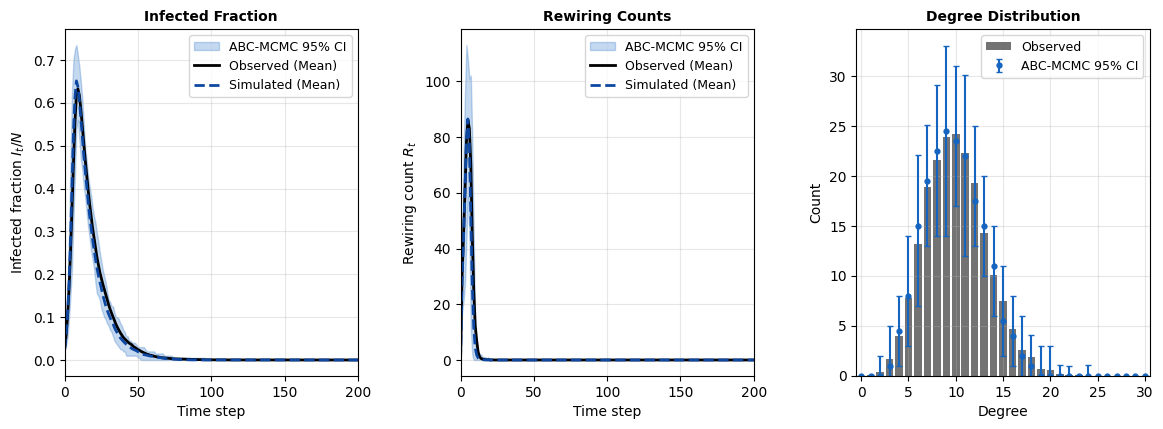

In [51]:
# --- POSTERIOR PREDICTIVE CHECK: 3-panel ABC-MCMC ---
beta_m  = np.median(chain_post[:, 0])
gamma_m = np.median(chain_post[:, 1])
rho_m   = np.median(chain_post[:, 2])
print(f'ABC-MCMC posterior medians: beta={beta_m:.4f}, gamma={gamma_m:.4f}, rho={rho_m:.4f}')

n_reps  = 40
rng_ppc = np.random.default_rng(42)
sim_inf_list, sim_rew_list, sim_deg_list = [], [], []
for _ in range(n_reps):
    inf, rew, deg = simulate(beta_m, gamma_m, rho_m, N=200, T=200, rng=rng_ppc)
    sim_inf_list.append(inf)
    sim_rew_list.append(rew)
    sim_deg_list.append(deg)

t_axis  = np.arange(201)
deg_arr = np.array(sim_deg_list)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4.5),
                                     gridspec_kw={'wspace': 0.35})

# --- Infected fraction ---
ax1.fill_between(t_axis,
    np.percentile(sim_inf_list,  2.5, axis=0),
    np.percentile(sim_inf_list, 97.5, axis=0),
    color='#1565C0', alpha=0.25, label='ABC-MCMC 95% CI')
ax1.plot(np.mean(obs_infected, axis=0), color='black',   lw=2.0, label='Observed (Mean)')
ax1.plot(np.mean(sim_inf_list, axis=0), color='#0d47a1', lw=2.0, ls='--', label='Simulated (Mean)')
ax1.set_xlabel('Time step', fontsize=10)
ax1.set_ylabel(r'Infected fraction $I_t/N$', fontsize=10)
ax1.set_title('Infected Fraction', fontsize=10, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3); ax1.set_xlim(0, 200)

# --- Rewiring counts ---
ax2.fill_between(t_axis,
    np.percentile(sim_rew_list,  2.5, axis=0),
    np.percentile(sim_rew_list, 97.5, axis=0),
    color='#1565C0', alpha=0.25, label='ABC-MCMC 95% CI')
ax2.plot(np.mean(obs_rewire, axis=0), color='black',   lw=2.0, label='Observed (Mean)')
ax2.plot(np.mean(sim_rew_list, axis=0), color='#0d47a1', lw=2.0, ls='--', label='Simulated (Mean)')
ax2.set_xlabel('Time step', fontsize=10)
ax2.set_ylabel(r'Rewiring count $R_t$', fontsize=10)
ax2.set_title('Rewiring Counts', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3); ax2.set_xlim(0, 200)

# --- Degree distribution ---
bins_deg     = np.arange(31)
obs_deg_mean = np.mean(obs_degree, axis=0)
sim_deg_mid  = np.median(deg_arr, axis=0)
sim_deg_lo   = np.percentile(deg_arr,  2.5, axis=0)
sim_deg_hi   = np.percentile(deg_arr, 97.5, axis=0)
yerr = np.array([sim_deg_mid - sim_deg_lo, sim_deg_hi - sim_deg_mid])
ax3.bar(bins_deg, obs_deg_mean, color='black', alpha=0.55, label='Observed', zorder=1)
ax3.errorbar(bins_deg, sim_deg_mid, yerr=yerr,
             fmt='o', color='#1565C0', capsize=2, ms=3.5,
             label='ABC-MCMC 95% CI', zorder=2)
ax3.set_xlabel('Degree', fontsize=10)
ax3.set_ylabel('Count', fontsize=10)
ax3.set_title('Degree Distribution', fontsize=10, fontweight='bold')
ax3.set_xlim(-0.5, 30.5); ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'mcmc_ppc.png'), dpi=200, bbox_inches='tight')
print('Saved: graphics/mcmc_ppc.png')
plt.show()


In [49]:
# ============================================================
# PRINT ALL NUMBERS FOR MAIN.TEX  (run this cell last)
# ============================================================

prior_std_arr = np.array([(0.50-0.05)/np.sqrt(12),
                           (0.20-0.02)/np.sqrt(12),
                           (0.80-0.00)/np.sqrt(12)])

print('=' * 80)
print('ALL NUMBERS FOR MAIN.TEX  --  seed=100')
print('=' * 80)

print('\n--- Tab 3: Rejection ABC (Informed, eps=5%) ---')
b5, g5, r5 = results['Informed']['5%']
for name, arr, ps in zip(['beta','gamma','rho'], [b5,g5,r5], prior_std_arr):
    med = np.median(arr)
    lo  = np.percentile(arr, 2.5)
    hi  = np.percentile(arr, 97.5)
    sh  = 1 - np.std(arr)/ps
    print(f'  {name}: median={med:.3f}  95%CI=[{lo:.3f},{hi:.3f}]  shrink={sh:.3f}')

print('\n--- Shrinkage at eps=5%: Baseline vs Informed ---')
for label in ['Baseline','Informed']:
    b, g, r = results[label]['5%']
    sb = 1 - np.std(b)/prior_std_arr[0]
    sg = 1 - np.std(g)/prior_std_arr[1]
    sr = 1 - np.std(r)/prior_std_arr[2]
    print(f'  {label}: beta={sb:.3f}  gamma={sg:.3f}  rho={sr:.3f}')

print('\n--- r(beta,rho) at eps=5% by data source ---')
for src_label, slc in [
    ('infected_fraction only',  slice(0,4)),
    ('+ rewire_counts',         slice(0,7)),
    ('+ degree_histograms',     slice(0,8)),
]:
    obs_s = obs_inform[slc]; sim_s = sim_inform[:,slc]
    d = normalised_distance(sim_s, obs_s)
    bb, gg, rr = run_ABC(d, 0.05)
    rval = safe_corr(bb, rr)
    print(f'  {src_label}: r(beta,rho)={rval:.3f}')

print(f'\n--- Tab 5: ABC-MCMC (eps=2%, {N_REPS_MCMC}-rep approx, post burn-in) ---')
for k, (name, ps) in enumerate(zip(['beta','gamma','rho'], prior_std_arr)):
    arr = chain_post[:,k]
    med = np.median(arr)
    lo  = np.percentile(arr, 2.5)
    hi  = np.percentile(arr, 97.5)
    sh  = 1 - np.std(arr)/ps
    print(f'  {name}: median={med:.3f}  95%CI=[{lo:.3f},{hi:.3f}]  shrink={sh:.3f}')
print(f'  Acceptance rate: {mcmc_acc_rate*100:.1f}%' if not np.isnan(mcmc_acc_rate) else '  Acceptance rate: (cached run — not recorded)')

print('\n--- Tab 6: Regression Adjustment stability table (median +/- std) ---')
print(f"{'Method & Threshold':<25} | {'beta':<18} | {'gamma':<18} | {'rho':<18}")
print('-'*90)
for label in ['Baseline','Informed']:
    for ql in Q_LABELS:
        res = adj_results[label][ql]
        m = np.median(res, axis=0); s = np.std(res, axis=0)
        print(f"{(label+' '+ql):<25} | {m[0]:.3f} +/- {s[0]:.3f}    "
              f"| {m[1]:.3f} +/- {s[1]:.3f}    | {m[2]:.3f} +/- {s[2]:.3f}")
    print('-'*90)

print('\n--- Reg-Adj Informed 10% (for Tab 7) ---')
ra10 = adj_results['Informed']['10%']
for k, (name, ps) in enumerate(zip(['beta','gamma','rho'], prior_std_arr)):
    med = np.median(ra10[:,k])
    lo  = np.percentile(ra10[:,k], 2.5)
    hi  = np.percentile(ra10[:,k], 97.5)
    sh  = 1 - np.std(ra10[:,k])/ps
    print(f'  {name}: median={med:.3f}  95%CI=[{lo:.3f},{hi:.3f}]  shrink={sh:.3f}')

print('\n' + '=' * 80)


ALL NUMBERS FOR MAIN.TEX  --  seed=100

--- Tab 3: Rejection ABC (Informed, eps=5%) ---
  beta: median=0.179  95%CI=[0.092,0.327]  shrink=0.522
  gamma: median=0.088  95%CI=[0.053,0.151]  shrink=0.505
  rho: median=0.297  95%CI=[0.157,0.498]  shrink=0.599

--- Shrinkage at eps=5%: Baseline vs Informed ---
  Baseline: beta=0.095  gamma=0.519  rho=0.419
  Informed: beta=0.522  gamma=0.505  rho=0.599

--- r(beta,rho) at eps=5% by data source ---
  infected_fraction only: r(beta,rho)=0.381
  + rewire_counts: r(beta,rho)=0.072
  + degree_histograms: r(beta,rho)=0.071

--- Tab 5: ABC-MCMC (eps=2%, 10-rep approx, post burn-in) ---
  beta: median=0.166  95%CI=[0.103,0.236]  shrink=0.729
  gamma: median=0.083  95%CI=[0.054,0.147]  shrink=0.564
  rho: median=0.285  95%CI=[0.175,0.420]  shrink=0.708
  Acceptance rate: 42.7%

--- Tab 6: Regression Adjustment stability table (median +/- std) ---
Method & Threshold        | beta               | gamma              | rho               
---------------